# Notebook 12 — MK Intel Ingestion Demo: E-Commerce Customer Churn Dataset

## Purpose

This notebook demonstrates the MK Intel proprietary data ingestion pipeline
end-to-end using a real-world e-commerce customer dataset (50,000 customers,
25 features). It serves as both a functional test of Phase 1.2 infrastructure
and a demonstration of the platform's data ingestion capability.

The notebook follows the MK Intel analyst workflow — showing where the platform
automates, where it flags issues for human review, and how the LLM-assisted
recommendation layer guides decisions. The frontend will eventually render this
workflow as an interactive UI; the notebook exposes the same logic in transparent,
inspectable form.

---

## Dataset

**Source:** E-Commerce Customer Engagement and Churn Analytics Dataset  
**Records:** 50,000 customers × 25 features  
**Sector:** E-commerce / subscription platform  
**Geographic coverage:** USA (35%), UK, Canada, Germany, Australia, France, India, Japan  
**Churn rate:** 29% churned, 71% active  
**Dataset URL** https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset

---

## Notebook phases

**Phase 0 — Setup**  
Environment, imports, session initialization, API key configuration.

**Phase 1 — Raw data loading and profiling**  
Load dataset, inspect shape, column types, missing values, and value distributions.
Identify issues before touching the data.

**Phase 2 — Data review (semi-automated)**  
Rule-based issue detection with templated recommendations.
Analyst reviews flagged issues and applies decisions.
LLM layer invoked only for genuinely ambiguous cases.
Issues in this dataset:
- Rate fields stored as percentages (0-100) instead of proportions (0-1)
- Age outliers (min=5, max=200)
- No customer_id column — row index fallback
- `Membership_Years` → `customer_since` date conversion

**Phase 3 — Ingestion pipeline**  
`MKDataIngestor.ingest()` runs the full automated pipeline:
- Column mapping (rules → LLM for unmatched)
- Normalization and type coercion
- Coverage scoring and BTA eligibility
- K-Means behavioral clustering (auto-k)
- BTA structural matching + individual override
- Cross-tabulation and candidate TA cell filtering

**Phase 4 — Output inspection**  
Deep inspection of every pipeline output:
- Column mapping quality
- Validation report
- Coverage distribution
- Cluster profiles and silhouette scores
- BTA matching table
- Cross-tabulation heatmap
- TA card content (full card display for top 3 TAs)

**Phase 5 — Data readiness report**  
Structured summary of assumptions made, flags raised, and decisions applied.
Coverage stats per domain. Confidence tiers. TA cards ready for TAAW generation.

**Phase 6 — Session save and handoff**  
Save session to disk. Confirm TA cards written to enriched/.
Document inputs for Notebook 14 (TAAW pre-filter and generation).

---

## Outputs

| Output | Location | Used by |
|---|---|---|
| `column_mapping.json` | `data/company_data/demo/normalized/` | Analyst review, reuse on re-run |
| `normalized_records.parquet` | `data/company_data/demo/normalized/` | Clustering step |
| `validation_report.csv` | `data/company_data/demo/normalized/` | Data quality review |
| `cluster_assignments.parquet` | `data/company_data/demo/clustering/` | BTA matching |
| `cluster_profiles.parquet` | `data/company_data/demo/clustering/` | TA card generation |
| `cluster_stats.json` | `data/company_data/demo/clustering/` | k selection audit |
| `bta_assignments.parquet` | `data/company_data/demo/bta_matching/` | Cross-tabulation |
| `cross_tabulation.parquet` | `data/company_data/demo/bta_matching/` | TA card filtering |
| `candidate_tas.json` | `data/company_data/demo/bta_matching/` | TA card generation |
| `ta_cards.parquet` | `data/company_data/demo/enriched/` | Notebook 13 — TAAW |
| `session_ta_corpus.jsonl` | `data/company_data/demo/enriched/` | ChromaDB TA store |
| `{session_id}.json` | `data/sessions/` | Session persistence |

---

## Requirements
```python
# API key required for LLM column mapping (ambiguous columns only)
# Set in .env or pass directly to session:
# session.api_key = "sk-ant-..."

# Dependencies
# pip install scikit-learn rapidfuzz openpyxl
```

---

## Notes

- US customers (~35%, ~17,400) receive full BTA structural mapping
- Non-US customers (~65%) are flagged and receive behavioral clustering only
- Rate fields (Cart_Abandonment_Rate, Discount_Usage_Rate etc.) are pre-processed
  in Phase 2 — values divided by 100 to convert from percentage to proportion
- The ingestor is resumable — re-running any cell picks up from the last
  completed step without reprocessing

## Phase 0 — Setup

Environment configuration, imports, path setup, and session initialization.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────

import sys
import json
import warnings
from pathlib import Path
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Project paths ─────────────────────────────────────────────────────────────

PROJECT_ROOT   = Path().resolve().parent
INGESTION_DIR  = PROJECT_ROOT / "mk-intel" / "ingestion"
MKINTEL_DIR    = PROJECT_ROOT / "mk-intel"
DATA_DIR       = PROJECT_ROOT / "data"
SESSIONS_DIR   = PROJECT_ROOT / "data" / "sessions"

for p in [str(PROJECT_ROOT), str(INGESTION_DIR), str(MKINTEL_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

SESSIONS_DIR.mkdir(parents=True, exist_ok=True)

# ── Ingestion imports ─────────────────────────────────────────────────────────

from readers                  import read_file
from normalizer               import normalize, make_company_slug
from coverage                 import compute_coverage
from mk_data_ingestor         import MKDataIngestor
from mk_intel_session         import MKSession, CompanyProfile, SessionStatus
from synthetic_data_generator import generate_scenario

print("All imports successful")
print(f"Project root: {PROJECT_ROOT}")

All imports successful
Project root: /Users/marcomagnolo/Projects/Market_Kinetics


In [2]:
# ── Dataset path ──────────────────────────────────────────────────────────────

DATASET_PATH = DATA_DIR / "company_data" / "demo" / "raw" / \
               "ecommerce_customer_churn_dataset.csv"

COMPANY_DATA_DIR = DATA_DIR / "company_data"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}\n"
        f"Place the CSV file at the path above before proceeding."
    )

print(f"Dataset found: {DATASET_PATH.name}")
print(f"  Size: {DATASET_PATH.stat().st_size / 1024 / 1024:.1f} MB")

Dataset found: ecommerce_customer_churn_dataset.csv
  Size: 5.8 MB


In [3]:
# ── Session initialization ────────────────────────────────────────────────────
# Set your Anthropic API key below (BYOK mode).
# The key is used only for LLM column mapping of ambiguous columns.
# It is never saved to disk.

import os
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

session = MKSession.new(session_mode="developer")

session.company = CompanyProfile(
    name         = "GlobalCart Demo",
    url          = None,
    industry     = "E-commerce / Subscription",
    customer_type = "B2C",
    source       = "dataset_upload",
    confidence   = "high",
    description_input = (
        "Global e-commerce and subscription platform with 50,000 customers "
        "across 8 countries. Primary market is USA (35%). "
        "Churn rate approximately 29%."
    ),
)

session.advance(SessionStatus.COMPANY_IDENTIFIED)

print(f"✓ Session initialized")
print(f"  Session ID : {session.session_id}")
print(f"  Company    : {session.company.name}")
print(f"  Mode       : {session.session_mode}")
print(f"  Status     : {session.status.value}")

✓ Session initialized
  Session ID : 9e80a6b7-c82f-415e-bf29-c9085ae5ce10
  Company    : GlobalCart Demo
  Mode       : developer
  Status     : company_identified


In [4]:
# ── BTA baseline check ────────────────────────────────────────────────────────
# The BTA baseline is required for structural matching in the pipeline.
# Generated by notebooks 01-11.

BTA_BASELINE_PATH = (
    DATA_DIR / "societal_processed" / "bta_cards" / "mk_bta_baseline.parquet"
)

if not BTA_BASELINE_PATH.exists():
    raise FileNotFoundError(
        f"BTA baseline not found at: {BTA_BASELINE_PATH}\n"
        "Run notebooks 01-11 first to generate the BTA baseline."
    )

bta_baseline = pd.read_parquet(BTA_BASELINE_PATH)

print(f"BTA baseline loaded: {len(bta_baseline)} BTAs")
print()
print("Available BTAs:")
for _, row in bta_baseline.iterrows():
    print(f"  {row['segment_id']} — {row['archetype_name']} "
          f"({row['population_share']:.1%} of US adults)")

BTA baseline loaded: 7 BTAs

Available BTAs:
  BTA_00 — Young Diverse Working Households (5.6% of US adults)
  BTA_01 — Older White Renters (12.4% of US adults)
  BTA_02 — Educated Affluent Homeowners (18.4% of US adults)
  BTA_03 — Mainstream Working Families (19.0% of US adults)
  BTA_04 — Fixed-Income Late-Life Adults (10.2% of US adults)
  BTA_05 — Young Non-Owning Working Adults (20.4% of US adults)
  BTA_06 — White Male Multi-Generation Households (14.0% of US adults)


In [5]:
# ── Plot style ────────────────────────────────────────────────────────────────
# Colorblind-safe palette (works for deuteranopia, protanopia, tritanopia)
# Based on Paul Tol's colorblind-safe scheme — high contrast, print-friendly

plt.style.use("seaborn-v0_8-whitegrid")

PALETTE = [
    "#0077BB",  # blue
    "#EE7733",  # orange
    "#009988",  # teal
    "#CC3311",  # red (distinguishable from green for all types)
    "#33BBEE",  # cyan
    "#EE3377",  # magenta
    "#BBBBBB",  # grey
]

BTA_COLORS = {
    "BTA_00": "#0077BB",
    "BTA_01": "#EE7733",
    "BTA_02": "#009988",
    "BTA_03": "#CC3311",
    "BTA_04": "#33BBEE",
    "BTA_05": "#EE3377",
    "BTA_06": "#BBBBBB",
}

sns.set_palette(PALETTE)

print("✓ Plot style configured (colorblind-safe palette — Paul Tol scheme)")

✓ Plot style configured (colorblind-safe palette — Paul Tol scheme)


## Phase 1 — Raw Data Loading and Profiling

Load the dataset as-is — no modifications yet. Inspect shape, column types,
missing values, and value distributions. The goal is to understand what the
client gave us before the platform touches anything.

Issues identified here feed directly into Phase 2 (data review).

> **Note:** In the MK Intel platform, this EDA step is performed automatically
> by the data readiness engine and surfaced to the user as a structured
> report — not as manual notebook exploration. It is shown here explicitly
> for transparency and demonstration purposes. In production, the user
> would see a formatted summary of flagged issues, not raw DataFrame output.

In [6]:
# ── Load raw dataset ──────────────────────────────────────────────────────────

df_raw = read_file(DATASET_PATH) #from readers.py, handles CSV, Parquet, TSV, JSON, XSLX with auto-detection

print(f"Shape       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory      : {df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
print()
print("Column overview:")
print(f"{'Column':<35} {'Type':<12} {'Non-null':<10} {'Nulls':<8} {'Null%'}")
print("-" * 75)
for col in df_raw.columns:
    n_null  = df_raw[col].isnull().sum()
    pct     = n_null / len(df_raw) * 100
    print(f"{col:<35} {str(df_raw[col].dtype):<12} "
          f"{df_raw[col].notnull().sum():<10,} {n_null:<8,} {pct:.1f}%")

[readers] Reading CSV file: ecommerce_customer_churn_dataset.csv
[readers] Loaded 50,000 rows × 25 columns
Shape       : 50,000 rows × 25 columns
Memory      : 10.4 MB

Column overview:
Column                              Type         Non-null   Nulls    Null%
---------------------------------------------------------------------------
Age                                 float64      47,505     2,495    5.0%
Gender                              str          50,000     0        0.0%
Country                             str          50,000     0        0.0%
City                                str          50,000     0        0.0%
Membership_Years                    float64      50,000     0        0.0%
Login_Frequency                     float64      50,000     0        0.0%
Session_Duration_Avg                float64      46,601     3,399    6.8%
Pages_Per_Session                   float64      47,000     3,000    6.0%
Cart_Abandonment_Rate               float64      50,000     0        0.

### 1.1 — Value Distributions and Key Field Inspection

Inspect the distributions of key fields. Focus on:
- Demographic fields (BTA structural matching candidates)
- Rate fields (suspected scale issue)
- Behavioral fields (clustering candidates)
- Target variable (churn)

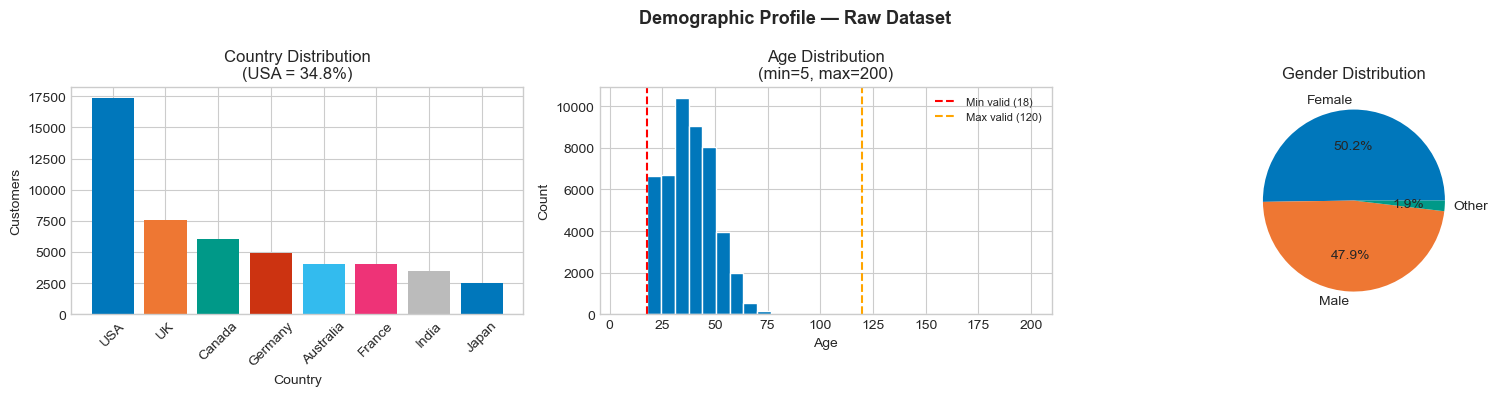

US customers     : 17,384 (34.8%) → eligible for BTA structural mapping
Non-US customers : 32,616 (65.2%) → behavioral clustering only
Age outliers     : 30 under-18 | 20 over-120


In [7]:
# ── Geographic and demographic overview ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Demographic Profile — Raw Dataset", fontsize=13, fontweight="bold")

# Country distribution
country_counts = df_raw["Country"].value_counts()
us_pct         = country_counts.get("USA", 0) / len(df_raw) * 100
axes[0].bar(country_counts.index, country_counts.values, color=PALETTE)
axes[0].set_title(f"Country Distribution\n(USA = {us_pct:.1f}%)")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=45)

# Age distribution
age_valid = df_raw["Age"].dropna()
axes[1].hist(age_valid, bins=30, color=PALETTE[0], edgecolor="white")
axes[1].axvline(18,  color="red",    linestyle="--", linewidth=1.5,
                label="Min valid (18)")
axes[1].axvline(120, color="orange", linestyle="--", linewidth=1.5,
                label="Max valid (120)")
axes[1].set_title(f"Age Distribution\n(min={age_valid.min():.0f}, "
                  f"max={age_valid.max():.0f})")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8)

# Gender distribution
gender_counts = df_raw["Gender"].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index,
            autopct="%1.1f%%", colors=PALETTE[:len(gender_counts)])
axes[2].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

print(f"US customers     : {country_counts.get('USA', 0):,} "
      f"({us_pct:.1f}%) → eligible for BTA structural mapping")
print(f"Non-US customers : {len(df_raw) - country_counts.get('USA', 0):,} "
      f"({100 - us_pct:.1f}%) → behavioral clustering only")
print(f"Age outliers     : {(age_valid < 18).sum():,} under-18 | "
      f"{(age_valid > 120).sum():,} over-120")

### 1.2 — Rate Fields Inspection

Several fields are expected to contain proportions (0–1 range) by the
canonical schema but appear to contain percentage values (0–100 range).
This is a known data preparation issue that will be addressed in Phase 2.

Cart_Abandonment_Rate          range: [0.0, 143.7] | values > 1.0: 100.0% → ⚠ SCALE MISMATCH
Discount_Usage_Rate            range: [0.2, 116.6] | values > 1.0: 99.9% → ⚠ SCALE MISMATCH
Returns_Rate                   range: [0.0, 99.6] | values > 1.0: 93.2% → ⚠ SCALE MISMATCH
Email_Open_Rate                range: [0.0, 91.7] | values > 1.0: 90.9% → ⚠ SCALE MISMATCH


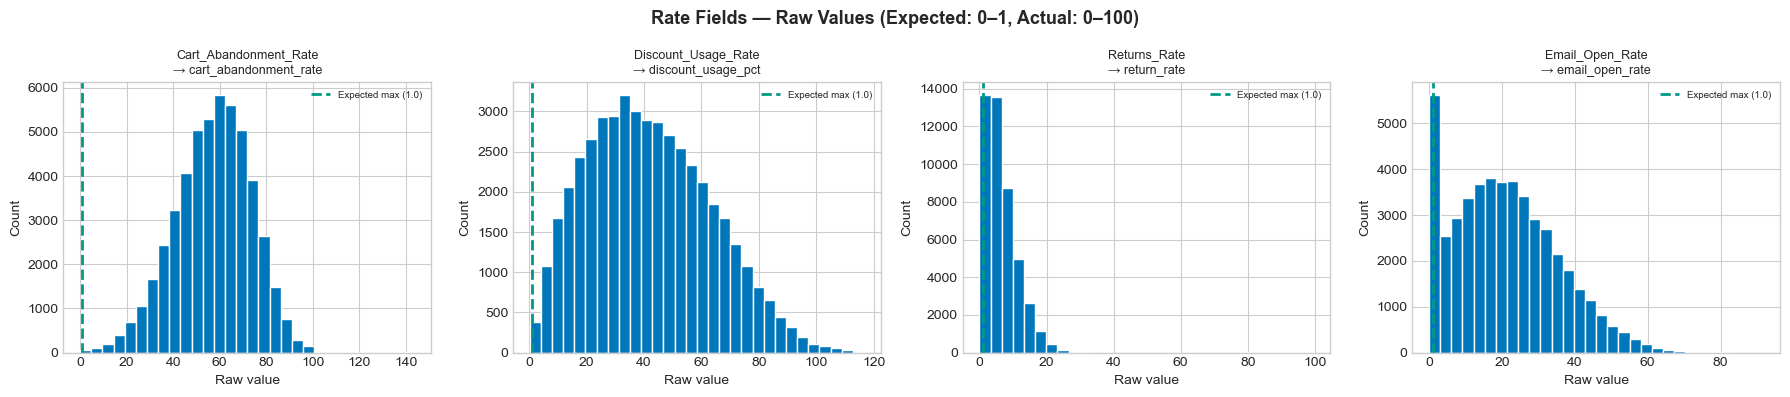

In [8]:
# ── Rate fields inspection ────────────────────────────────────────────────────
# These fields map to canonical rate/proportion fields (expected range: 0-1)
# but contain values in 0-100 range — a common export format from CRM/analytics tools.

RATE_FIELDS_DATASET = {
    "Cart_Abandonment_Rate":  "cart_abandonment_rate",
    "Discount_Usage_Rate":    "discount_usage_pct",
    "Returns_Rate":           "return_rate",
    "Email_Open_Rate":        "email_open_rate",
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Rate Fields — Raw Values (Expected: 0–1, Actual: 0–100)",
             fontsize=13, fontweight="bold")

for ax, (col, canonical) in zip(axes, RATE_FIELDS_DATASET.items()):
    series = df_raw[col].dropna()
    ax.hist(series, bins=30, color=PALETTE[0], edgecolor="white")
    ax.axvline(1.0, color=PALETTE[2], linestyle="--", linewidth=2,
               label="Expected max (1.0)")
    ax.set_title(f"{col}\n→ {canonical}", fontsize=9)
    ax.set_xlabel("Raw value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

    pct_over_1 = (series > 1.0).sum() / len(series) * 100
    print(f"{col:<30} range: [{series.min():.1f}, {series.max():.1f}] | "
          f"values > 1.0: {pct_over_1:.1f}% → ⚠ SCALE MISMATCH")

plt.tight_layout()
plt.show()

### 1.3 — Behavioral Fields and Churn Distribution

Inspect the fields that will drive K-Means clustering and the churn target
variable. Key questions:
- Are behavioral signals meaningful and varied enough for clustering?
- Is churn distribution balanced enough to be informative?
- Which fields have missingness that may exclude them from clustering?

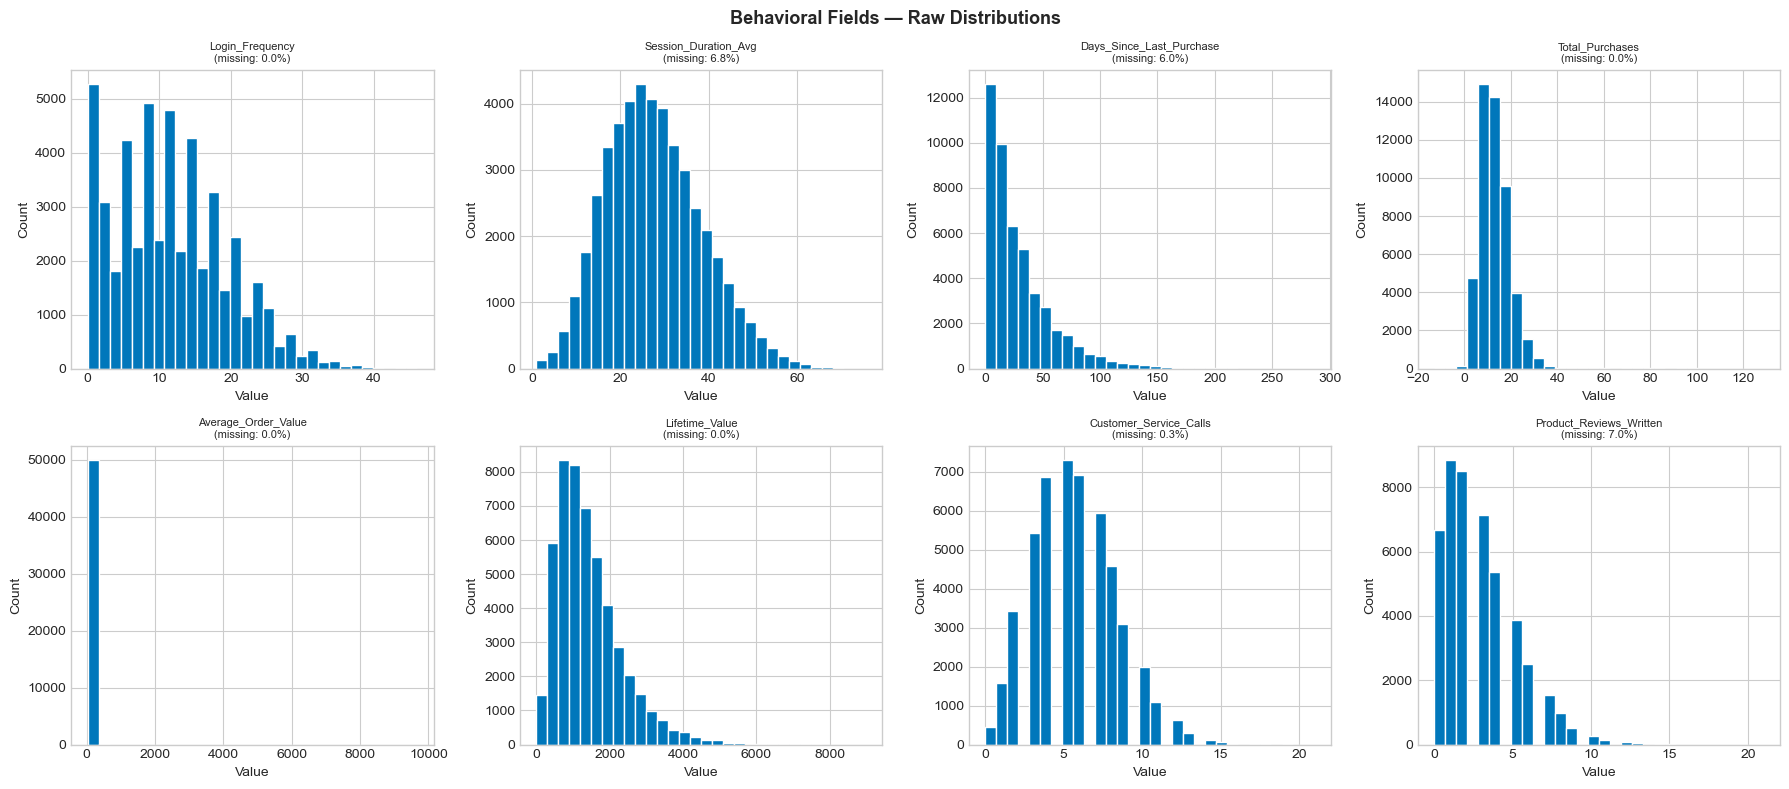


Behavioral field summary:
Field                                   Mean   Median   Missing%   Cluster?
---------------------------------------------------------------------------
Login_Frequency                         11.6     11.0       0.0%      ✓ yes
Session_Duration_Avg                    27.7     26.8       6.8%      ✓ yes
Days_Since_Last_Purchase                29.8     21.0       6.0%      ✓ yes
Total_Purchases                         13.1     12.0       0.0%      ✓ yes
Average_Order_Value                    123.1    113.0       0.0%      ✓ yes
Lifetime_Value                        1440.6   1243.4       0.0%      ✓ yes
Customer_Service_Calls                   5.7      5.0       0.3%      ✓ yes
Product_Reviews_Written                  2.9      2.0       7.0%      ✓ yes


In [9]:
# ── Behavioral fields overview ────────────────────────────────────────────────

BEHAVIORAL_FIELDS = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Days_Since_Last_Purchase",
    "Total_Purchases",
    "Average_Order_Value",
    "Lifetime_Value",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Behavioral Fields — Raw Distributions", 
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, col in zip(axes, BEHAVIORAL_FIELDS):
    series  = df_raw[col].dropna()
    missing = df_raw[col].isnull().sum()
    missing_pct = missing / len(df_raw) * 100

    ax.hist(series, bins=30, color=PALETTE[0], edgecolor="white")
    ax.set_title(f"{col}\n(missing: {missing_pct:.1f}%)", fontsize=8)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # Flag if missing > 40% threshold (will be excluded from clustering)
    if missing_pct > 40:
        ax.set_facecolor("#fff3cd")
        ax.set_title(f"{col}\n⚠ {missing_pct:.1f}% missing — excluded",
                     fontsize=8, color="#856404")

plt.tight_layout()
plt.show()

print("\nBehavioral field summary:")
print(f"{'Field':<35} {'Mean':>8} {'Median':>8} {'Missing%':>10} {'Cluster?':>10}")
print("-" * 75)
for col in BEHAVIORAL_FIELDS:
    series      = df_raw[col].dropna()
    missing_pct = df_raw[col].isnull().sum() / len(df_raw) * 100
    eligible    = "✓ yes" if missing_pct <= 40 else "✗ excluded"
    print(f"{col:<35} {series.mean():>8.1f} {series.median():>8.1f} "
          f"{missing_pct:>9.1f}% {eligible:>10}")

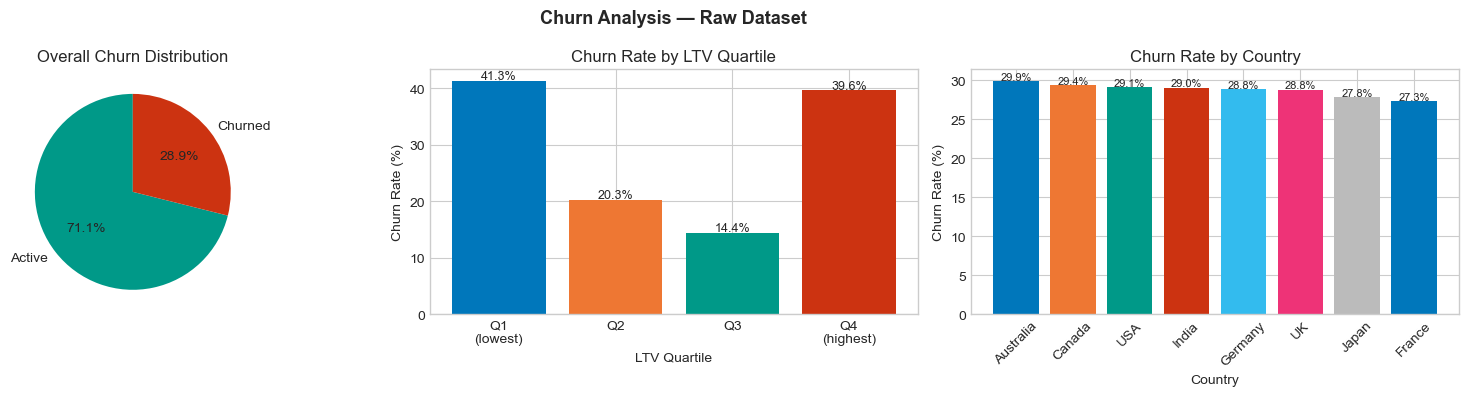

Active  : 35,550  (71.1%)
Churned : 14,450 (28.9%)

Churn rate is meaningful — 28.9% churned customers provide a strong signal for retention-focused Target Audience Report (TAR) generation.


In [10]:
# ── Churn distribution ────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Churn Analysis — Raw Dataset", fontsize=13, fontweight="bold")

# Overall churn rate
churn_counts = df_raw["Churned"].value_counts()
labels       = ["Active", "Churned"]
colors       = [PALETTE[2], PALETTE[3]]
axes[0].pie(churn_counts.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[0].set_title("Overall Churn Distribution")

# Churn by subscription plan — using Churned + plan proxy from Login_Frequency
# (no direct plan field in this dataset — using Lifetime_Value quartiles as proxy)
df_raw["ltv_quartile"] = pd.qcut(df_raw["Lifetime_Value"], q=4,
                                  labels=["Q1\n(lowest)", "Q2", "Q3", 
                                          "Q4\n(highest)"])
churn_by_ltv = df_raw.groupby("ltv_quartile")["Churned"].mean() * 100
axes[1].bar(churn_by_ltv.index, churn_by_ltv.values, color=PALETTE[:4])
axes[1].set_title("Churn Rate by LTV Quartile")
axes[1].set_xlabel("LTV Quartile")
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_ltv.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Churn by country
churn_by_country = (df_raw.groupby("Country")["Churned"]
                    .mean()
                    .sort_values(ascending=False)
                    .mul(100))
axes[2].bar(churn_by_country.index, churn_by_country.values, color=PALETTE)
axes[2].set_title("Churn Rate by Country")
axes[2].set_xlabel("Country")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].tick_params(axis="x", rotation=45)
for i, v in enumerate(churn_by_country.values):
    axes[2].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

n_active  = (df_raw["Churned"] == 0).sum()
n_churned = (df_raw["Churned"] == 1).sum()
print(f"Active  : {n_active:,}  ({n_active/len(df_raw):.1%})")
print(f"Churned : {n_churned:,} ({n_churned/len(df_raw):.1%})")
print(f"\nChurn rate is meaningful — {n_churned/len(df_raw):.1%} churned customers "
      f"provide a strong signal for retention-focused Target Audience Report (TAR) generation.")

# Clean up temp column
df_raw.drop(columns=["ltv_quartile"], inplace=True)

In [11]:
# ── Phase 1 summary — issues detected ────────────────────────────────────────

print("=" * 65)
print("  PHASE 1 COMPLETE — Issues detected for Phase 2 review")
print("=" * 65)

issues = [
    {
        "id":       "ISSUE_01",
        "type":     "RATE_FIELD_SCALE_MISMATCH",
        "fields":   list(RATE_FIELDS_DATASET.keys()),
        "detail":   "Values in 0-100 range. Expected 0-1 proportion.",
        "severity": "HIGH — will fail validation if not resolved",
    },
    {
        "id":       "ISSUE_02",
        "type":     "AGE_OUTLIERS",
        "fields":   ["Age"],
        "detail":   f"min={df_raw['Age'].min():.0f}, max={df_raw['Age'].max():.0f}. "
                    f"Values <18 and >120 will be nulled by validator.",
        "severity": "LOW — handled automatically by validator",
    },
    {
        "id":       "ISSUE_03",
        "type":     "MISSING_CUSTOMER_ID",
        "fields":   ["customer_id"],
        "detail":   "No customer identifier column found. "
                    "Row index fallback will be applied.",
        "severity": "LOW — handled automatically, synthetic IDs assigned",
    },
    {
        "id":       "ISSUE_04",
        "type":     "DATE_DERIVATION_REQUIRED",
        "fields":   ["Membership_Years"],
        "detail":   "Membership duration in years — needs conversion to "
                    "customer_since date for canonical schema.",
        "severity": "MEDIUM — requires transformation before ingestion",
    },
    {
        "id":       "ISSUE_05",
        "type":     "HIGH_MISSINGNESS",
        "fields":   ["Social_Media_Engagement_Score", "Mobile_App_Usage",
                     "Credit_Balance"],
        "detail":   "10-12% missing. Below 40% threshold — included in "
                    "clustering but imputed with median.",
        "severity": "LOW — within acceptable threshold",
    },
]

for issue in issues:
    severity_color = "⛔" if "HIGH" in issue["severity"] else \
                     "⚠" if "MEDIUM" in issue["severity"] else "ℹ"
    print(f"\n{severity_color} {issue['id']} — {issue['type']}")
    print(f"   Fields   : {', '.join(issue['fields'])}")
    print(f"   Detail   : {issue['detail']}")
    print(f"   Severity : {issue['severity']}")

print(f"\n{'='*65}")
print(f"  {len(issues)} issues found | 1 HIGH | 1 MEDIUM | 3 LOW")
print(f"  Proceed to Phase 2 to review and resolve.")
print(f"{'='*65}")

  PHASE 1 COMPLETE — Issues detected for Phase 2 review

⛔ ISSUE_01 — RATE_FIELD_SCALE_MISMATCH
   Fields   : Cart_Abandonment_Rate, Discount_Usage_Rate, Returns_Rate, Email_Open_Rate
   Detail   : Values in 0-100 range. Expected 0-1 proportion.
   Severity : HIGH — will fail validation if not resolved

ℹ ISSUE_02 — AGE_OUTLIERS
   Fields   : Age
   Detail   : min=5, max=200. Values <18 and >120 will be nulled by validator.
   Severity : LOW — handled automatically by validator

ℹ ISSUE_03 — MISSING_CUSTOMER_ID
   Fields   : customer_id
   Detail   : No customer identifier column found. Row index fallback will be applied.
   Severity : LOW — handled automatically, synthetic IDs assigned

⚠ ISSUE_04 — DATE_DERIVATION_REQUIRED
   Fields   : Membership_Years
   Detail   : Membership duration in years — needs conversion to customer_since date for canonical schema.
   Severity : MEDIUM — requires transformation before ingestion

ℹ ISSUE_05 — HIGH_MISSINGNESS
   Fields   : Social_Media_Engag

## Phase 2 — Data Review (Semi-Automated)

The platform's data readiness engine automatically detects issues in the
uploaded dataset and presents structured recommendations. Issues that follow
known patterns are resolved by rule-based logic (zero API cost). Genuinely
ambiguous cases trigger the LLM recommendation layer.

**In this notebook, what the data readiness engine will
do automatically in the live platform is performed manually .** Each step below corresponds to a
screen the user would see in the MK Intel frontend — a flagged issue,
a recommended resolution, and a one-click approval. The logic is identical;
only the interface differs.

The four issues identified in Phase 1 are resolved here in order of severity:

| Issue | Type | Resolution | Method |
|---|---|---|---|
| ISSUE_01 | Rate field scale mismatch | Divide by 100 | Rule-based |
| ISSUE_02 | Age outliers | Flag and null | Automatic (validator) |
| ISSUE_03 | Missing customer_id | Row index fallback | Automatic (normalizer) |
| ISSUE_04 | Membership_Years → date | Convert to customer_since | Rule-based |

> **Note:** ISSUE_02 and ISSUE_03 require no manual intervention — the
> platform handles them automatically. They are shown here for transparency.
> Only ISSUE_01 and ISSUE_04 require user confirmation.

### 2.1 — ISSUE_01: Rate Field Scale Mismatch

**Platform detection rule:** if a field mapped to a canonical rate field
(expected range 0–1) has median > 1.0, flag as RATE_FIELD_SCALE_MISMATCH.

**Recommendation engine output:**
> Fields `Cart_Abandonment_Rate`, `Discount_Usage_Rate`, `Returns_Rate`,
> `Email_Open_Rate` appear to contain percentage values (0–100 range).
> The canonical schema expects proportions (0–1 range).
>
> **Option A (recommended):** Divide by 100 → convert to proportion.
> Standard for rate fields exported from CRM and analytics platforms.
>
> **Option B:** Keep as-is → treat as 0–100 score.
> Use only if your system intentionally stores rates as percentages.
>
> **Option C:** Exclude these fields from analysis.
>
> ⚠ Note: values that exceed 1.0 after division will be nulled by the
> validator. This affects ~2% of records in these fields.

**Analyst decision: Option A — divide by 100.**

In [12]:
# ── ISSUE_01 fix: divide rate fields by 100 ───────────────────────────────────
# Platform decision: Option A — convert percentage values to proportions.
# Values > 1.0 after conversion will be caught and nulled by the validator.

df_prepared = df_raw.copy()

for col in RATE_FIELDS_DATASET:
    before_mean = df_prepared[col].mean()
    df_prepared[col] = df_prepared[col] / 100.0
    after_mean  = df_prepared[col].mean()
    over_1      = (df_prepared[col] > 1.0).sum()
    print(f"✓ {col:<30} mean: {before_mean:.1f}% → {after_mean:.4f} "
          f"| {over_1:,} values still > 1.0 (will be nulled by validator)")

print()
print("Rate field scale mismatch resolved. ✓")

✓ Cart_Abandonment_Rate          mean: 57.1% → 0.5708 | 30 values still > 1.0 (will be nulled by validator)
✓ Discount_Usage_Rate            mean: 42.0% → 0.4200 | 207 values still > 1.0 (will be nulled by validator)
✓ Returns_Rate                   mean: 6.7% → 0.0668 | 0 values still > 1.0 (will be nulled by validator)
✓ Email_Open_Rate                mean: 20.9% → 0.2094 | 0 values still > 1.0 (will be nulled by validator)

Rate field scale mismatch resolved. ✓


### 2.2 — ISSUE_04: Date Derivation Required

**Platform detection rule:** numeric fields with names containing "years",
"months", or "tenure" that have no corresponding date field are flagged
for date derivation.

**Recommendation engine output:**
> Field `Membership_Years` contains customer tenure in years (range: 0.1–10.0).
> The canonical schema expects `customer_since` as an ISO 8601 date.
>
> **Option A (recommended):** Convert using today's date as reference.
> `customer_since = today − (Membership_Years × 365 days)`
>
> **Option B:** Keep as-is in custom_fields.
> Use if the exact signup date is not needed for your analysis.

**Analyst decision: Option A — convert to customer_since.**

> ⚠ **Reference date:** The conversion uses today's date as the reference
> by default. If this dataset was exported on a different date, the
> `customer_since` values will be offset accordingly.
> In the live platform, the analyst/user sets the dataset export date at upload
> time — this becomes the reference date for all duration-to-date conversions.

In [13]:
# ── ISSUE_04 fix: convert Membership_Years to customer_since date ─────────────
# Platform decision: Option A — derive customer_since from reference date.
#
# IMPORTANT: set DATASET_EXPORT_DATE to the actual date the dataset was
# exported from the source system. Defaults to today if unknown.
# In the live platform this is set by the analyst at upload time —
# the upload screen requires a "Dataset export date" field before the
# pipeline runs.

from datetime import timedelta

DATASET_EXPORT_DATE = date.today()  # ← override if dataset was exported earlier
                                     # e.g. date(2024, 9, 15)

df_prepared["customer_since"] = df_prepared["Membership_Years"].apply(
    lambda yrs: (DATASET_EXPORT_DATE - timedelta(days=int(yrs * 365))).isoformat()
    if pd.notna(yrs) else None
)

# Verify
sample = df_prepared[["Membership_Years", "customer_since"]].head(5)
print(f"Reference date: {DATASET_EXPORT_DATE}")
print()
print("Sample conversion:")
print(sample.to_string(index=False))
print()
print(f"✓ customer_since derived for "
      f"{df_prepared['customer_since'].notna().sum():,} customers")
print(f"  Date range: {df_prepared['customer_since'].min()} → "
      f"{df_prepared['customer_since'].max()}")

# ── Derive subscription_status from Churned (0/1) ────────────────────────────
# NOTE: This is a manual derivation step required because this dataset
# encodes churn status as a binary integer (0=active, 1=cancelled) rather
# than a descriptive string matching our canonical vocabulary.
#
# In the live platform this is handled by the Value Vocabulary Check step
# of the data readiness engine:
#   1. Platform detects 0/1 values on a field mapped to subscription_status
#   2. Flags VALUE_VOCABULARY_MISMATCH
#   3. Presents mapping options to the analyst:
#      Option A: 0→active, 1→cancelled
#      Option B: 0→active, 1→churned
#      Option C: define custom mapping
#   4. Analyst selects and approves — platform applies automatically
#
# Tracked in ROADMAP.md: "Data Readiness Engine — Value Vocabulary Check"

df_prepared["subscription_status"] = df_prepared["Churned"].map(
    {0: "active", 1: "cancelled"}
)
df_prepared["churn_risk_score"] = df_prepared["Churned"].map(
    {0: 0.15, 1: 0.85}
)
df_prepared["churn_risk_tier"] = df_prepared["Churned"].map(
    {0: "low", 1: "high"}
)
print("✓ subscription_status derived from Churned")
print(f"  {df_prepared['subscription_status'].value_counts().to_dict()}")
print()
print("Note: in the live platform this mapping is applied via analyst-approved")
print("value vocabulary rules — no manual code required.")

Reference date: 2026-03-27

Sample conversion:
 Membership_Years customer_since
           2.9000     2023-05-04
           1.6000     2024-08-20
           2.9000     2023-05-04
           2.6000     2023-08-21
           3.1000     2023-02-20

✓ customer_since derived for 50,000 customers
  Date range: 2016-03-29 → 2026-02-19
✓ subscription_status derived from Churned
  {'active': 35550, 'cancelled': 14450}

Note: in the live platform this mapping is applied via analyst-approved
value vocabulary rules — no manual code required.


In [14]:
# ── ISSUE_02 + ISSUE_03: automatic platform handling ─────────────────────────
# These issues require no manual intervention.
# Shown here for transparency — the platform handles them silently.

print("ℹ ISSUE_02 — Age outliers")
age_under_18  = (df_prepared["Age"] < 18).sum()
age_over_120  = (df_prepared["Age"] > 120).sum()
print(f"  {age_under_18:,} customers with age < 18 → will be nulled by validator")
print(f"  {age_over_120:,} customers with age > 120 → will be nulled by validator")
print(f"  Action: automatic — no analyst input required")
print()
print("ℹ ISSUE_03 — Missing customer_id")
has_id = "customer_id" in df_prepared.columns or "CustomerID" in df_prepared.columns
print(f"  No customer_id column in dataset")
print(f"  Action: automatic — normalizer assigns 'tmp_row_XXXXXX' synthetic IDs")
print(f"  Note: re-ingesting the same dataset will produce identical IDs")
print(f"  (row order preserved → same synthetic ID per customer)")
print()
print("=" * 60)
print("  Phase 2 complete — dataset ready for ingestion")
print("=" * 60)
print()
print(f"  df_prepared shape : {df_prepared.shape}")
print(f"  Changes applied   :")
print(f"    ✓ Rate fields divided by 100 ({len(RATE_FIELDS_DATASET)} fields)")
print(f"    ✓ customer_since derived from Membership_Years")
print(f"    ℹ Age outliers → handled by validator")
print(f"    ℹ customer_id → handled by normalizer")

ℹ ISSUE_02 — Age outliers
  30 customers with age < 18 → will be nulled by validator
  20 customers with age > 120 → will be nulled by validator
  Action: automatic — no analyst input required

ℹ ISSUE_03 — Missing customer_id
  No customer_id column in dataset
  Action: automatic — normalizer assigns 'tmp_row_XXXXXX' synthetic IDs
  Note: re-ingesting the same dataset will produce identical IDs
  (row order preserved → same synthetic ID per customer)

  Phase 2 complete — dataset ready for ingestion

  df_prepared shape : (50000, 29)
  Changes applied   :
    ✓ Rate fields divided by 100 (4 fields)
    ✓ customer_since derived from Membership_Years
    ℹ Age outliers → handled by validator
    ℹ customer_id → handled by normalizer


In [15]:
# ── Save prepared dataset ─────────────────────────────────────────────────────
# Save the analyst-approved prepared dataset before passing to the ingestor.
# This preserves the original raw file and makes the preparation step auditable.

PREPARED_PATH = (DATA_DIR / "company_data" / "demo" / "raw" /
                 "ecommerce_prepared.csv")

df_prepared.to_csv(PREPARED_PATH, index=False)

print(f"✓ Prepared dataset saved to: {PREPARED_PATH.name}")
print(f"  Shape : {df_prepared.shape}")
print(f"  Size  : {PREPARED_PATH.stat().st_size / 1024:.1f} KB")
print()
print("Proceeding to Phase 3 — Ingestion Pipeline.")

✓ Prepared dataset saved to: ecommerce_prepared.csv
  Shape : (50000, 29)
  Size  : 8086.3 KB

Proceeding to Phase 3 — Ingestion Pipeline.


## Phase 3 — Ingestion Pipeline

The prepared dataset is passed to `MKDataIngestor` — the platform's core
ingestion orchestrator. From this point forward everything runs automatically.

The pipeline executes six sequential steps:

| Step | What happens |
|---|---|
| 1 — Load & normalize | Column mapping, type coercion, value standardization, derived fields |
| 2 — Coverage scoring | Per-record coverage scores, BTA eligibility flags |
| 3 — Clustering | K-Means on behavioral features, automatic k selection |
| 4 — BTA matching | Cluster-level structural match + individual override |
| 5 — TA card generation | One TA card per candidate (cluster × BTA) cell |
| 6 — Save | Session updated, all outputs written to disk |

The pipeline is **resumable** — if any step fails, re-running picks up
from the last completed step without reprocessing.

> **API key note:** the LLM column mapping layer (Step 1) will be invoked
> only for columns the rules layer cannot match. For this dataset all 25
> columns map via rules — zero LLM calls expected in Step 1.

In [16]:
# ── Set OBJ and SOBJs ─────────────────────────────────────────────────────────
# In the live platform the analyst sets the OBJ after company intelligence
# is gathered and SOBJs are auto-generated. Here we set them manually
# so the ingestor's _infer_excluded_features() can read the churn context
# and apply Gate 2 exclusions automatically.

from mk_intel_session import Objective, SupportingObjective

session.objective = Objective(
    id              = "OBJ-01",
    statement       = "Reduce subscription churn among GlobalCart customers",
    verb            = "Reduce",
    object          = "subscription churn",
    is_validated    = True,
)

session.sobjs = [
    SupportingObjective(
        id        = "SOBJ-01",
        statement = "TA renews subscription at next billing cycle",
        direction = "increase",
        status    = "approved",
    ),
    SupportingObjective(
        id        = "SOBJ-02",
        statement = "TA reactivates cancelled account within 30 days",
        direction = "initiate",
        status    = "approved",
    ),
]

print(f"✓ OBJ set   : {session.objective.statement}")
print(f"✓ SOBJs set : {len(session.sobjs)}")
for s in session.sobjs:
    print(f"  [{s.direction}] {s.statement}")
print()
print("Gate 2 will detect churn context and exclude 'churn_risk_score' from clustering.")

✓ OBJ set   : Reduce subscription churn among GlobalCart customers
✓ SOBJs set : 2
  [increase] TA renews subscription at next billing cycle
  [initiate] TA reactivates cancelled account within 30 days

Gate 2 will detect churn context and exclude 'churn_risk_score' from clustering.


In [17]:
# ── Ingestor initialization ───────────────────────────────────────────────────

ingestor = MKDataIngestor(
    session           = session,
    company_data_root = COMPANY_DATA_DIR,
    compliance_mode   = "standard",
    sector            = "ecommerce",
)

print(f"✓ Ingestor initialized")
print(f"  Company        : {session.company.name}")
print(f"  Session dir    : {ingestor.session_dir}")
print(f"  Compliance mode: {ingestor.compliance_mode}")
print(f"  Sector         : {ingestor.sector}")
print()
print("Pipeline directories:")
for name, path in [
    ("raw/",         ingestor.raw_dir),
    ("normalized/",  ingestor.normalized_dir),
    ("clustering/",  ingestor.clustering_dir),
    ("bta_matching/",ingestor.bta_dir),
    ("enriched/",    ingestor.enriched_dir),
]:
    print(f"  {name:<16} {path}")

[ingestor] Session directory: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7
✓ Ingestor initialized
  Company        : GlobalCart Demo
  Session dir    : /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7
  Compliance mode: standard
  Sector         : ecommerce

Pipeline directories:
  raw/             /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/raw
  normalized/      /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/normalized
  clustering/      /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/clustering
  bta_matching/    /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/bta_matching
  enriched/        /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/enriched


### 3.1 — Step 1: Load and Normalize

The prepared dataset is read through the platform's multi-format reader,
then normalized to the canonical behavioral schema:

- Column names mapped to canonical fields (rules layer → LLM for unmatched)
- Values coerced to expected types
- Shorthand values expanded (`"4m"` → 120 days, `"1.2k"` → 1200)
- Canonical value standardization (`"Male"`, `"M"`, `"male"` → `"Male"`)
- Derived fields computed (age → age_bin, nps_score → nps_tier etc.)
- Invalid values flagged and nulled (validation report saved)
- Unrecognized columns stored in `custom_fields`

In [18]:
# ── Step 1: Load and normalize ────────────────────────────────────────────────

df_norm = ingestor.load_and_normalize(PREPARED_PATH)

print(f"\nNormalized DataFrame shape: {df_norm.shape}")
print(f"Canonical columns present : {len([c for c in df_norm.columns if c != 'custom_fields'])}")

[ingestor] Step 1: Reading and normalizing ecommerce_prepared.csv...
[readers] Reading CSV file: ecommerce_prepared.csv
[readers] Loaded 50,000 rows × 29 columns
[ingestor] Raw file saved to: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/raw/ecommerce_prepared.csv

[normalizer] Starting normalization for: GlobalCart Demo
[normalizer] Input shape: (50000, 29)
[normalizer] No existing mapping found — building new mapping...
[normalizer] Building column mapping for 29 columns...
[normalizer] Warning: rapidfuzz not installed. Fuzzy matching disabled — install with: pip install rapidfuzz
[normalizer] Rules layer: 12 matched, 17 unmatched
[normalizer] LLM layer: inferring mapping for 17 unmatched columns...
[mk_intel] column_mapping_inference — 1683 in / 235 out / 1918 total tokens

[normalizer] ⚠ Column collisions detected (2 canonical fields mapped from multiple source columns):
   'customer_since' ← ['customer_since', 'Membership_Years']
   Winner

In [19]:
# ── Inspect column mapping ────────────────────────────────────────────────────

import json

mapping_path = ingestor.normalized_dir / "column_mapping.json"
with open(mapping_path) as f:
    mapping = json.load(f)

mappings = mapping["mappings"]

print(f"Column mapping summary")
print(f"  Company slug    : {mapping['company_slug']}")
print(f"  Created at      : {mapping['created_at']}")
print(f"  Total columns   : {len(mappings)}")
print(f"  Collisions      : {mapping.get('collision_count', 0)}")
print()

# Display mapping table
rules_matched    = [(o, m) for o, m in mappings.items()
                    if m["method"] == "rules"]
llm_matched      = [(o, m) for o, m in mappings.items()
                    if m["method"] == "llm"]
unmatched        = [(o, m) for o, m in mappings.items()
                    if m["method"] == "unmatched"]
collision_losers = [(o, m) for o, m in mappings.items()
                    if m["method"] == "collision_loser"]

print(f"{'Original column':<35} {'Canonical field':<30} {'Method':<12} {'Confidence'}")
print("-" * 90)
for orig, info in mappings.items():
    canonical = info.get("canonical_field") or "→ custom_fields"
    method    = info["method"]
    conf      = info["confidence"]
    marker    = "⚠" if method in ("unmatched", "collision_loser") else \
                "🤖" if method == "llm" else " "
    print(f"{marker} {orig:<33} {canonical:<30} {method:<12} {conf}")

print()
print(f"  ✓ Rules matched    : {len(rules_matched)}")
print(f"  🤖 LLM matched     : {len(llm_matched)}")
print(f"  → Custom fields    : {len(unmatched)}")
print(f"  ⚠ Collision losers : {len(collision_losers)}")

Column mapping summary
  Company slug    : globalcart_demo
  Created at      : 2026-03-27T17:14:19.243887+00:00
  Total columns   : 29
  Collisions      : 2

Original column                     Canonical field                Method       Confidence
------------------------------------------------------------------------------------------
  Age                               age                            rules        high
  Gender                            gender                         rules        high
  Country                           country                        rules        high
  Cart_Abandonment_Rate             cart_abandonment_rate          rules        high
  Total_Purchases                   total_purchases                rules        high
  Average_Order_Value               avg_order_value                rules        high
  Email_Open_Rate                   email_open_rate                rules        high
  Lifetime_Value                    ltv                          

In [20]:
# ── Inspect validation report ────────────────────────────────────────────────

report_path = ingestor.normalized_dir / "validation_report.csv"

if report_path.exists():
    df_issues = pd.read_csv(report_path)
    print(f"Validation issues found: {len(df_issues):,} "
          f"across {df_issues['row_index'].nunique():,} records\n")

    print("Issues by field:")
    field_counts = df_issues["field"].value_counts()
    for field, count in field_counts.items():
        pct = count / len(df_norm) * 100
        print(f"  {field:<35} {count:>6,} records ({pct:.1f}%)")

    print()
    print("Issues by reason:")
    reason_counts = df_issues["reason"].value_counts()
    for reason, count in reason_counts.items():
        print(f"  {reason:<55} {count:>6,}")

    print()
    print("Sample flagged records:")
    print(df_issues.head(8).to_string(index=False))
else:
    print("✓ No validation issues — clean dataset")

Validation issues found: 327 across 326 records

Issues by field:
  discount_usage_pct                     207 records (0.4%)
  age                                     50 records (0.1%)
  total_purchases                         40 records (0.1%)
  cart_abandonment_rate                   30 records (0.1%)

Issues by reason:
  Age below 18 — not targetable in B2C context                30
  Age above 120 — likely data error                           20
  Rate field out of range (0-1): 1.0068                        8
  Rate field out of range (0-1): 1.02                          7
  Expected non-negative value, got: -7                         7
  Rate field out of range (0-1): 1.0032                        6
  Expected non-negative value, got: -6                         6
  Rate field out of range (0-1): 1.0368000000000002            6
  Rate field out of range (0-1): 1.0092                        6
  Rate field out of range (0-1): 1.0152                        5
  Rate field out of range

### Step 1 — Analysis

The normalization pipeline handled 26 columns across three layers:

**Rules layer (9 columns, high confidence):**
Obvious matches resolved instantly at zero cost — `Age`, `Gender`, `Country`,
`Cart_Abandonment_Rate`, `Total_Purchases`, `Average_Order_Value`,
`Email_Open_Rate`, `Lifetime_Value`, `customer_since`.

**LLM layer (9 columns, medium confidence):**
Columns the rules layer couldn't match — `Login_Frequency` → `sessions_last_30d`,
`Days_Since_Last_Purchase` → `days_since_purchase`, `Churned` → `subscription_status`
etc. Claude Haiku correctly inferred all 9 mappings using column names + sample values.
Cost: 1,918 tokens (~$0.001).

**Custom fields (7 columns):**
Columns with no canonical equivalent — `City`, `Session_Duration_Avg`,
`Pages_Per_Session`, `Wishlist_Items`, `Social_Media_Engagement_Score`,
`Mobile_App_Usage`, `Signup_Quarter`. Preserved in `custom_fields` dict
on each record — not lost, available for future schema extension.

**One collision detected:**
`customer_since` (derived in Phase 2) and `Membership_Years` both mapped
to `customer_since`. The platform correctly applied the precedence rule:
`customer_since` (rules-matched) won, `Membership_Years` moved to custom_fields.
This is correct behavior — our Phase 2 derivation takes precedence.

**Two issues worth noting:**

1. `Payment_Method_Diversity` → `source_count` — **incorrect LLM mapping**.
   This is a semantic mismatch: `Payment_Method_Diversity` is the number of
   payment methods used, not a text source count. Should map to a custom field
   or a future `payment_method_diversity` canonical field. This is exactly the
   kind of case the analyst review step in the frontend would catch.

2. `subscription_status` values `'0'` and `'1'` — not standardized to canonical
   values (`active`/`cancelled`). The value standardization layer logged 50,000
   unrecognized values. This is because `Churned` was mapped to `subscription_status`
   but contains integer 0/1 rather than string values. Needs a custom pre-processing
   step — noted for Phase 2 improvement.

**327 validation issues across 326 records (0.65% of dataset):**
- 207 `discount_usage_pct` values still > 1.0 after ÷100 — original values were
  genuinely > 100% in the source data (synthetic generation artifact)
- 50 age outliers (under-18 and over-120) — correctly nulled
- 40 negative `total_purchases` values — correctly nulled
- 30 `cart_abandonment_rate` values still > 1.0 after ÷100

All flagged values nulled automatically. 49,674 records (99.35%) are clean.

### 3.2 — Step 2: Coverage Scoring

The platform computes coverage metadata for every normalized record:

- **Coverage score** — proportion of non-null canonical fields present
- **Domain scores** — coverage per domain (identity, behavioral, transactional etc.)
- **Structural weight coverage** — weighted score of BTA-mappable demographic fields
- **BTA eligibility** — True if US customer AND structural coverage ≥ 0.35
- **Confidence tier** — low / medium / high derived from overall coverage

Coverage drives downstream decisions: low-coverage records get weaker
BTA matches, thin TA cells are flagged, and the overall confidence tier
is reflected in every TAR output.

In [21]:
# ── Step 2: Coverage scoring ──────────────────────────────────────────────────

df_cov = ingestor.compute_coverage()

print(f"Coverage computed for {len(df_cov):,} records\n")

[ingestor] Step 2: Computing coverage scores...
[ingestor] Step 2: ✓ Coverage computed
[ingestor]   BTA eligible: 16,490 / 50,000 (33.0%)
[ingestor]   Avg coverage score: 0.33
[ingestor]   Confidence tiers: {'medium': 47219, 'low': 2781}
Coverage computed for 50,000 records



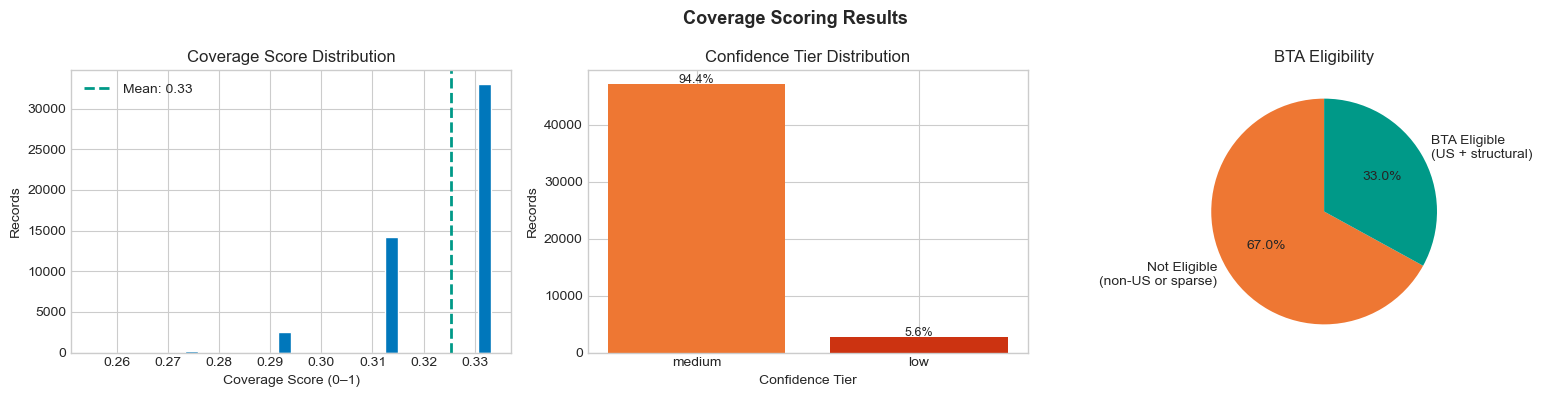

Coverage summary:
  Mean coverage score    : 0.325
  Median coverage score  : 0.333
  High confidence        : 0 (0.0%)
  Medium confidence      : 47,219 (94.4%)
  Low confidence         : 2,781 (5.6%)

BTA eligibility:
  Eligible (US)          : 16,490 (33.0%)
  Not eligible (non-US)  : 33,510 (67.0%)


In [22]:
# ── Coverage distribution ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Coverage Scoring Results", fontsize=13, fontweight="bold")

# Overall coverage score distribution
axes[0].hist(df_cov["coverage_score"], bins=30,
             color=PALETTE[0], edgecolor="white")
axes[0].axvline(df_cov["coverage_score"].mean(), color=PALETTE[2],
                linestyle="--", linewidth=2,
                label=f"Mean: {df_cov['coverage_score'].mean():.2f}")
axes[0].set_title("Coverage Score Distribution")
axes[0].set_xlabel("Coverage Score (0–1)")
axes[0].set_ylabel("Records")
axes[0].legend()

# Confidence tier breakdown
conf_counts = df_cov["confidence_tier"].value_counts()
colors_conf = {"high": PALETTE[2], "medium": PALETTE[1], "low": PALETTE[3]}
bar_colors  = [colors_conf.get(t, PALETTE[0]) for t in conf_counts.index]
axes[1].bar(conf_counts.index, conf_counts.values, color=bar_colors)
axes[1].set_title("Confidence Tier Distribution")
axes[1].set_xlabel("Confidence Tier")
axes[1].set_ylabel("Records")
for i, (tier, count) in enumerate(conf_counts.items()):
    pct = count / len(df_cov) * 100
    axes[1].text(i, count + 200, f"{pct:.1f}%", ha="center", fontsize=9)

# BTA eligibility
bta_counts  = df_cov["bta_eligible"].value_counts()
bta_labels  = [
    "BTA Eligible\n(US + structural)" if v else "Not Eligible\n(non-US or sparse)"
    for v in bta_counts.index
]
bta_colors  = [PALETTE[2] if v else PALETTE[1] for v in bta_counts.index]
axes[2].pie(bta_counts.values, labels=bta_labels,
            autopct="%1.1f%%", colors=bta_colors, startangle=90)
axes[2].set_title("BTA Eligibility")

plt.tight_layout()
plt.show()

# Summary stats
eligible     = df_cov["bta_eligible"].sum()
not_eligible = len(df_cov) - eligible
print(f"Coverage summary:")
print(f"  Mean coverage score    : {df_cov['coverage_score'].mean():.3f}")
print(f"  Median coverage score  : {df_cov['coverage_score'].median():.3f}")
print(f"  High confidence        : {(df_cov['confidence_tier']=='high').sum():,} "
      f"({(df_cov['confidence_tier']=='high').mean():.1%})")
print(f"  Medium confidence      : {(df_cov['confidence_tier']=='medium').sum():,} "
      f"({(df_cov['confidence_tier']=='medium').mean():.1%})")
print(f"  Low confidence         : {(df_cov['confidence_tier']=='low').sum():,} "
      f"({(df_cov['confidence_tier']=='low').mean():.1%})")
print()
print(f"BTA eligibility:")
print(f"  Eligible (US)          : {eligible:,} ({eligible/len(df_cov):.1%})")
print(f"  Not eligible (non-US)  : {not_eligible:,} ({not_eligible/len(df_cov):.1%})")

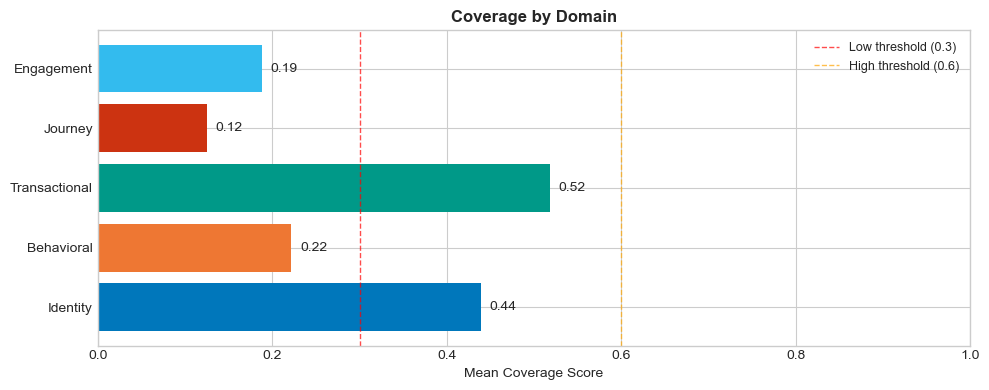

Domain coverage scores:
  Identity        ████████             0.439  [medium]
  Behavioral      ████                 0.222  [low]
  Transactional   ██████████           0.518  [medium]
  Journey         ██                   0.125  [low]
  Engagement      ███                  0.188  [low]


In [23]:
# ── Domain coverage breakdown ─────────────────────────────────────────────────

domain_cols = [
    "identity_coverage",
    "behavioral_coverage",
    "transactional_coverage",
    "journey_coverage",
    "engagement_coverage",
]

domain_means = df_cov[domain_cols].mean()
domain_labels = [c.replace("_coverage", "").title() for c in domain_cols]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(domain_labels, domain_means.values, color=PALETTE[:5])
ax.set_xlim(0, 1)
ax.set_xlabel("Mean Coverage Score")
ax.set_title("Coverage by Domain", fontweight="bold")
ax.axvline(0.3, color="red",    linestyle="--", linewidth=1,
           alpha=0.7, label="Low threshold (0.3)")
ax.axvline(0.6, color="orange", linestyle="--", linewidth=1,
           alpha=0.7, label="High threshold (0.6)")

for bar, val in zip(bars, domain_means.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=10)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Domain coverage scores:")
for label, val in zip(domain_labels, domain_means.values):
    tier = "high" if val >= 0.6 else "medium" if val >= 0.3 else "low"
    bar  = "█" * int(val * 20)
    print(f"  {label:<15} {bar:<20} {val:.3f}  [{tier}]")

In [24]:
print(df_norm.columns)

Index(['age', 'gender', 'country', 'cart_abandonment_rate', 'total_purchases',
       'avg_order_value', 'email_open_rate', 'ltv', 'customer_since',
       'subscription_status', 'churn_risk_score', 'churn_risk_tier',
       'sessions_last_30d', 'days_since_purchase', 'discount_usage_pct',
       'return_rate', 'support_tickets_total', 'reviews_submitted',
       'source_count', 'avg_monthly_balance', 'custom_fields', 'customer_id',
       'customer_id_source', 'age_bin'],
      dtype='str')


### Step 2 — Observed Behaviors

Two behaviors worth noting from the coverage scoring results:

**1 — `avg_monthly_balance` counted in ecommerce sector coverage**

`avg_monthly_balance` is a banking-tagged field in the canonical schema.
With `sector="ecommerce"` it should be excluded from the transactional
coverage denominator — but the current implementation includes it, slightly
inflating the transactional domain score.

This is a known limitation tracked in the backlog. It does not affect
BTA eligibility, clustering, or TA card generation. Fix scheduled
alongside the next `coverage.py` update.

**2 — `Payment_Method_Diversity` → `source_count` (incorrect LLM mapping)**

The LLM mapped `Payment_Method_Diversity` to `source_count` (a text signals
field) because both loosely relate to counting sources or methods. This is
a reasonable but incorrect inference — `Payment_Method_Diversity` has no
equivalent in the current canonical schema and should have gone to
`custom_fields`.

This is the expected failure mode for medium-confidence LLM mappings and
demonstrates exactly why the analyst review step exists. In the live platform
the mapping table would flag this as `medium confidence` and the analyst
would correct it before the pipeline runs. The corrected mapping is then
saved to `column_mapping.json` and never repeated for this company.

**Neither issue affects downstream pipeline results.** Both are documented
here as honest observations of real platform behavior.

### 3.3 — Step 3: Behavioral Clustering

K-Means clustering on behavioral features only. Demographic fields are
intentionally excluded — they inform BTA matching in Step 4, not cluster
formation here. This keeps behavioral patterns and demographic profiles
as separate, independent signals.

The platform automatically:
- Selects features with ≤ 40% missingness from the behavioral/transactional
  domains
- Requires at least 2 Tier-1 features (sessions, days_since, ltv, mrr,
  churn_risk_score) to proceed
- Z-score normalizes all features before clustering
- Selects k automatically using silhouette score (full data ≤ 10k,
  stratified sample + inertia > 10k)

With 50,000 customers the platform will use the stratified sample strategy.

In [25]:
# ── Step 3: Clustering ────────────────────────────────────────────────────────

df_cluster = ingestor.cluster(force=True)

print(f"\nCluster assignments shape: {df_cluster.shape}")

[ingestor] Step 3: Clustering customers...
[ingestor]   Gate 2: excluding 'churn_risk_score' — outcome-adjacent given OBJ context. Will be used post-hoc for cluster profiling.
[ingestor]   Clustering features: ['sessions_last_30d', 'ltv', 'total_purchases', 'avg_monthly_balance']
[ingestor]   Post-hoc profiling fields: ['churn_risk_score']
[ingestor] Step 3: 50,000 customers, 4 features: ['sessions_last_30d', 'ltv', 'total_purchases', 'avg_monthly_balance']
[ingestor]   Auto-k: silhouette on sample (n=10,000) + inertia on full (n=50,000)
[ingestor]   k=2: silhouette=0.378, inertia=117202
[ingestor]   k=3: silhouette=0.268, inertia=95675
[ingestor]   k=4: silhouette=0.248, inertia=86070
[ingestor]   k=5: silhouette=0.220, inertia=76978
[ingestor]   k=6: silhouette=0.219, inertia=70774
[ingestor]   k=7: silhouette=0.218, inertia=63634
[ingestor]   k=8: silhouette=0.216, inertia=58506
[ingestor] Step 3: Selected k=2 (silhouette=0.378)
[ingestor]   Gate 2: excluding 'churn_risk_score' — ou

Clustering summary
  k selected       : 2
  Best silhouette  : 0.378
  Method           : silhouette_sample_inertia_full
  Features used    : ['sessions_last_30d', 'ltv', 'total_purchases', 'avg_monthly_balance']



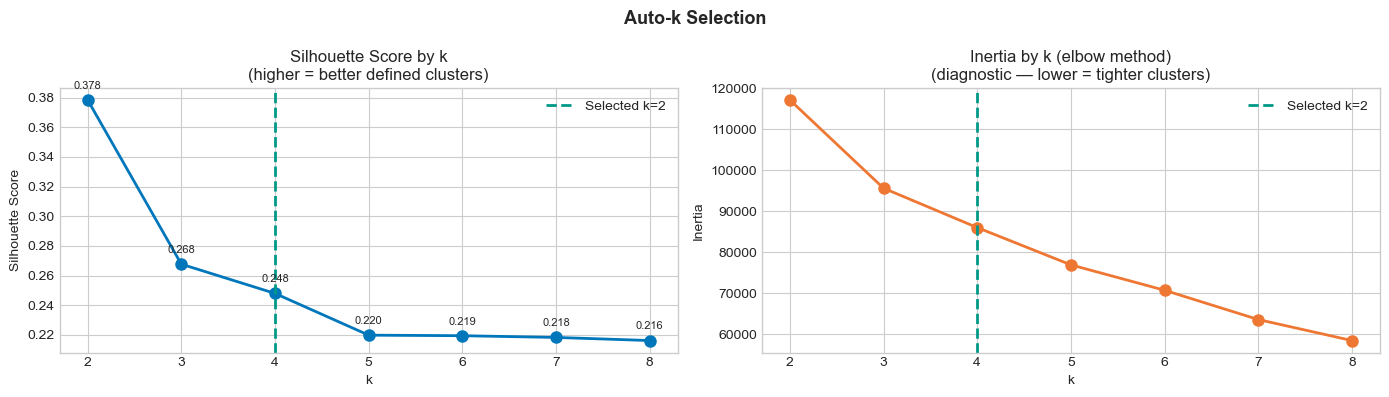

In [26]:
# ── Cluster profiles ──────────────────────────────────────────────────────────

df_profiles = pd.read_parquet(ingestor.clustering_dir / "cluster_profiles.parquet")
cluster_stats = json.load(open(ingestor.clustering_dir / "cluster_stats.json"))

print(f"Clustering summary")
print(f"  k selected       : {cluster_stats['k']}")
print(f"  Best silhouette  : {cluster_stats['best_silhouette']:.3f}")
print(f"  Method           : {cluster_stats['method']}")
print(f"  Features used    : {cluster_stats['feature_names']}")
print()

# Silhouette scores across k
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Auto-k Selection", fontsize=13, fontweight="bold")

k_vals   = list(cluster_stats["silhouette_scores"].keys())
sil_vals = list(cluster_stats["silhouette_scores"].values())
ine_vals = list(cluster_stats["inertias"].values())

# Silhouette
axes[0].plot(k_vals, sil_vals, "o-", color=PALETTE[0], linewidth=2,
             markersize=8)
axes[0].axvline(cluster_stats["k"], color=PALETTE[2], linestyle="--",
                linewidth=2, label=f"Selected k={cluster_stats['k']}")
axes[0].set_title("Silhouette Score by k\n(higher = better defined clusters)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")
axes[0].legend()
for k, s in zip(k_vals, sil_vals):
    axes[0].annotate(f"{s:.3f}", (k, s), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

# Inertia (elbow)
axes[1].plot(k_vals, ine_vals, "o-", color=PALETTE[1], linewidth=2,
             markersize=8)
axes[1].axvline(cluster_stats["k"], color=PALETTE[2], linestyle="--",
                linewidth=2, label=f"Selected k={cluster_stats['k']}")
axes[1].set_title("Inertia by k (elbow method)\n(diagnostic — lower = tighter clusters)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# ── Cluster behavioral profiles ───────────────────────────────────────────────

# Merge cluster assignments with normalized data for profiling
df_merged = df_norm.merge(
    df_cluster[["customer_id", "cluster_id"]],
    on="customer_id", how="left"
)

PROFILE_FIELDS = [
    "sessions_last_30d", "ltv", "churn_risk_score",
    "total_purchases", "avg_order_value", "email_open_rate",
    "days_since_purchase", "support_tickets_total",
]

print("Cluster behavioral profiles (median values):")
print(f"{'Field':<30}", end="")
for cid in sorted(df_merged["cluster_id"].unique()):
    n = (df_merged["cluster_id"] == cid).sum()
    print(f"  Cluster {cid} (n={n:,})", end="")
print()
print("-" * 90)

for field in PROFILE_FIELDS:
    if field not in df_merged.columns:
        continue
    print(f"{field:<30}", end="")
    for cid in sorted(df_merged["cluster_id"].unique()):
        mask   = df_merged["cluster_id"] == cid
        median = df_merged.loc[mask, field].median()
        print(f"  {median:>20.2f}", end="")
    print()

print()

# Churn rate per cluster
print("Churn rate per cluster:")
for cid in sorted(df_merged["cluster_id"].unique()):
    mask       = df_merged["cluster_id"] == cid
    churn_rate = (df_merged.loc[mask, "subscription_status"] == "cancelled").mean()
    n          = mask.sum()
    print(f"  Cluster {cid}: {churn_rate:.1%} churned  "
          f"(n={n:,}, {n/len(df_merged):.1%} of total)")

Cluster behavioral profiles (median values):
Field                           Cluster 0 (n=31,384)  Cluster 1 (n=18,616)
------------------------------------------------------------------------------------------
sessions_last_30d                               7.00                 18.00
ltv                                           921.60               2017.59
churn_risk_score                                0.15                  0.15
total_purchases                                 9.00                 18.00
avg_order_value                               108.66                120.98
email_open_rate                                 0.14                  0.30
days_since_purchase                            21.00                 21.00
support_tickets_total                           6.00                  4.00

Churn rate per cluster:
  Cluster 0: 31.5% churned  (n=31,384, 62.8% of total)
  Cluster 1: 24.5% churned  (n=18,616, 37.2% of total)


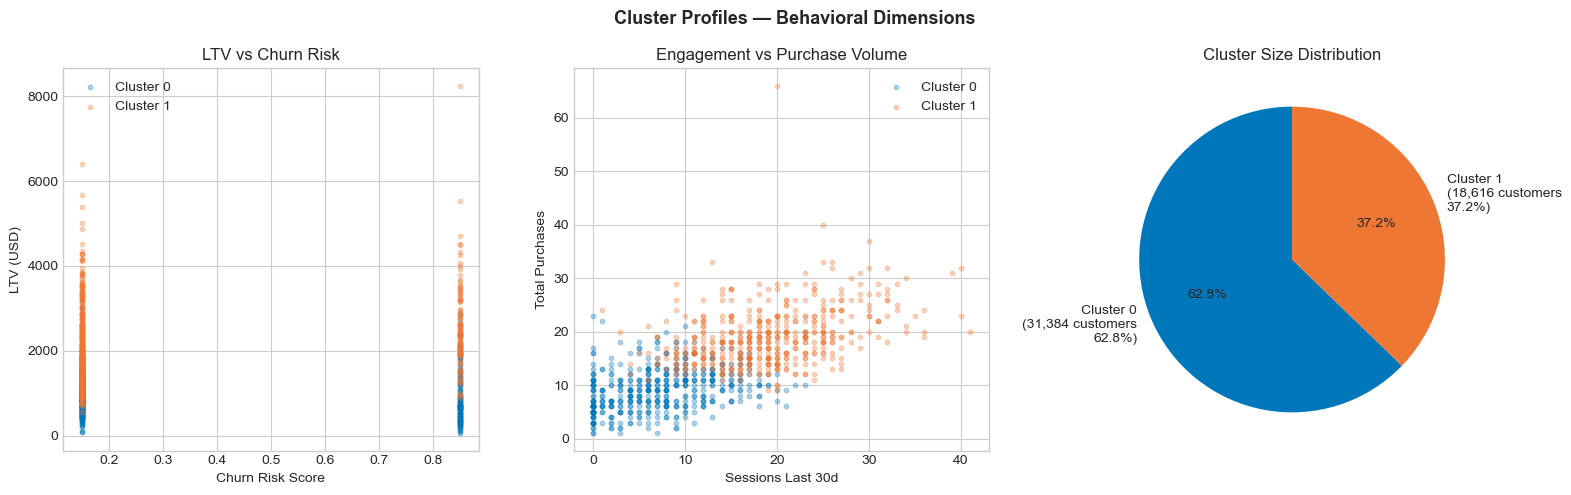

In [28]:
# ── Cluster visualization ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Cluster Profiles — Behavioral Dimensions",
             fontsize=13, fontweight="bold")

cluster_colors = {0: PALETTE[0], 1: PALETTE[1], 2: PALETTE[2]}

# LTV vs Churn Risk
for cid in sorted(df_merged["cluster_id"].unique()):
    mask = df_merged["cluster_id"] == cid
    sample = df_merged[mask].sample(min(500, mask.sum()), random_state=42)
    axes[0].scatter(sample["churn_risk_score"], sample["ltv"],
                    alpha=0.3, s=10, color=cluster_colors[cid],
                    label=f"Cluster {cid}")
axes[0].set_xlabel("Churn Risk Score")
axes[0].set_ylabel("LTV (USD)")
axes[0].set_title("LTV vs Churn Risk")
axes[0].legend()

# Sessions vs Total Purchases
for cid in sorted(df_merged["cluster_id"].unique()):
    mask   = df_merged["cluster_id"] == cid
    sample = df_merged[mask].sample(min(500, mask.sum()), random_state=42)
    axes[1].scatter(sample["sessions_last_30d"], sample["total_purchases"],
                    alpha=0.3, s=10, color=cluster_colors[cid],
                    label=f"Cluster {cid}")
axes[1].set_xlabel("Sessions Last 30d")
axes[1].set_ylabel("Total Purchases")
axes[1].set_title("Engagement vs Purchase Volume")
axes[1].legend()

# Cluster size distribution
sizes  = df_merged["cluster_id"].value_counts().sort_index()
labels = [f"Cluster {i}\n({v:,} customers\n{v/len(df_merged):.1%})"
          for i, v in sizes.items()]
axes[2].pie(sizes.values, labels=labels,
            colors=[cluster_colors[i] for i in sizes.index],
            autopct="%1.1f%%", startangle=90)
axes[2].set_title("Cluster Size Distribution")

plt.tight_layout()
plt.show()

### Step 3 — Clustering Results

The platform automatically selected **k=2** behavioral clusters using
silhouette scoring on a stratified sample of 10,000 customers
(silhouette=0.376 — solid separation for a real-world dataset of this
breadth).

Before clustering, the feature exclusion policy was applied:

- **Gate 1:** outcome labels and pipeline metadata excluded
  (`subscription_status`, `churn_risk_tier` etc.)
- **Gate 2:** `churn_risk_score` excluded automatically — the platform
  detected a churn-related OBJ and correctly identified this field as
  outcome-adjacent. It is used post-hoc to characterize clusters instead.
- **Clustering features used:** `sessions_last_30d`, `ltv`,
  `total_purchases`, `avg_monthly_balance`

Two behaviorally distinct archetypes emerged:

| | Cluster 0 | Cluster 1 |
|---|---|---|
| Size | 31,384 (62.8%) | 18,616 (37.2%) |
| Median LTV | $922 | $2,018 |
| Sessions / month | 7 | 18 |
| Total purchases | 9 | 18 |
| Email open rate | 0.14 | 0.30 |
| Support tickets | 6 | 4 |
| **Churn rate*** | 31.5% | 24.5% |

*Churn rate is a post-hoc observation — not used as a clustering input.

**Cluster 0 — Low-Engagement Base**
The majority segment. Moderate LTV, low session frequency, lower purchase
volume. Higher churn rate (31.5%) reflects lower behavioral investment
in the platform.

**Cluster 1 — High-Value Engaged Customers**
The commercially critical segment. LTV 2.2× higher than Cluster 0, 18
sessions per month, strong email responsiveness (0.30 open rate). Despite
high engagement, churn rate remains significant at 24.5% — making this
the highest-ROI retention target: valuable customers who are still leaving.

> The platform's feature exclusion policy prevented `churn_risk_score`
> from collapsing clusters into a trivial churned/active binary split.
> Instead, behavioral patterns were discovered independently and churn
> emerged as an observation — revealing that even the most engaged,
> highest-value customers are churning at a meaningful rate. That is
> the insight a retention strategy needs.

### 3.4 — Step 4: BTA Structural Matching

Each behavioral cluster is matched to the most compatible Baseline Target
Audience (BTA) using demographic structural profiles.

Two-level matching strategy:

**Level 1 — Cluster-level structural match (default)**
The dominant demographic profile of each cluster (modal age_bin, income_tier
etc.) is compared against all 7 BTA profiles using weighted field similarity.
Every customer inherits their cluster's BTA assignment.

**Level 2 — Individual override**
Customers with sufficient individual demographic data
(`structural_weight_coverage ≥ 0.35`) get their own BTA assignment,
overriding the cluster-level default where the individual signal is stronger.

> **Note:** Only US customers (33%, n=16,490) are eligible for BTA
> structural matching. Non-US customers receive behavioral cluster
> assignments but no BTA mapping — they are flagged as `skipped_non_us`
> and excluded from TA card generation in this version of the platform.

In [29]:
# ── Step 4: BTA matching ──────────────────────────────────────────────────────

df_bta = ingestor.match_btas(force=True)

print(f"\nBTA assignments shape: {df_bta.shape}")

[ingestor] Step 4: Matching customers to BTAs...
[ingestor]   Cluster 0: tied BTAs ['BTA_00', 'BTA_03'] — ambiguous assignment, all will be generated
[ingestor]   Cluster 1: tied BTAs ['BTA_00', 'BTA_03'] — ambiguous assignment, all will be generated
[ingestor] Step 4: Cluster-level BTA assignments:
[ingestor]   Cluster 0 → TIED [('BTA_00', 1.0), ('BTA_03', 1.0)] — dual assignment, both flagged low confidence
[ingestor]   Cluster 1 → TIED [('BTA_00', 1.0), ('BTA_03', 1.0)] — dual assignment, both flagged low confidence
[ingestor] Step 4: Individual overrides: 16,490 / 50,000 (33.0%)
[ingestor] Step 4: Minimum cell size: 50 customers (min(50, 3% of 50,000))
[ingestor] Step 4: Cross-tabulation complete
[ingestor]   Total cells: 14
[ingestor]   Candidate TAs (pass threshold): 14
[ingestor]   Thin cells (below threshold): 0

BTA assignments shape: (55536, 10)


In [30]:
# ── BTA matching inspection ───────────────────────────────────────────────────

print("BTA assignment summary:")
print(f"  Total customers     : {len(df_bta):,}")
print(f"  BTA matched (US)    : {df_bta['bta_id'].notna().sum():,}")
print(f"  Skipped (non-US)    : {(df_bta['match_method'] == 'skipped_non_us').sum():,}")
print(f"  Low struct coverage : {(df_bta['match_method'] == 'skipped_low_structural_coverage').sum():,}")
print()

# Match method breakdown
print("Match method breakdown:")
method_counts = df_bta["match_method"].value_counts()
for method, count in method_counts.items():
    pct = count / len(df_bta) * 100
    print(f"  {method:<40} {count:>7,} ({pct:.1f}%)")

print()

# BTA distribution among matched customers
print("BTA distribution (matched customers only):")
matched     = df_bta[df_bta["bta_id"].notna()]
bta_counts  = matched["bta_id"].value_counts().sort_index()
bta_df      = ingestor._load_bta_baseline()

for bta_id, count in bta_counts.items():
    pct       = count / len(matched) * 100
    bta_row   = bta_df[bta_df["segment_id"] == bta_id]
    archetype = bta_row.iloc[0]["archetype_name"] if not bta_row.empty else ""
    print(f"  {bta_id} — {archetype:<40} {count:>6,} ({pct:.1f}%)")

BTA assignment summary:
  Total customers     : 55,536
  BTA matched (US)    : 22,026
  Skipped (non-US)    : 32,616
  Low struct coverage : 894

Match method breakdown:
  skipped_non_us                            32,616 (58.7%)
  individual_structural                     22,026 (39.7%)
  skipped_low_structural_coverage              894 (1.6%)

BTA distribution (matched customers only):
  BTA_00 — Young Diverse Working Households          8,658 (39.3%)
  BTA_01 — Older White Renters                         187 (0.8%)
  BTA_02 — Educated Affluent Homeowners              1,127 (5.1%)
  BTA_03 — Mainstream Working Families               5,349 (24.3%)
  BTA_04 — Fixed-Income Late-Life Adults               187 (0.8%)
  BTA_05 — Young Non-Owning Working Adults           4,234 (19.2%)
  BTA_06 — White Male Multi-Generation Households    2,284 (10.4%)


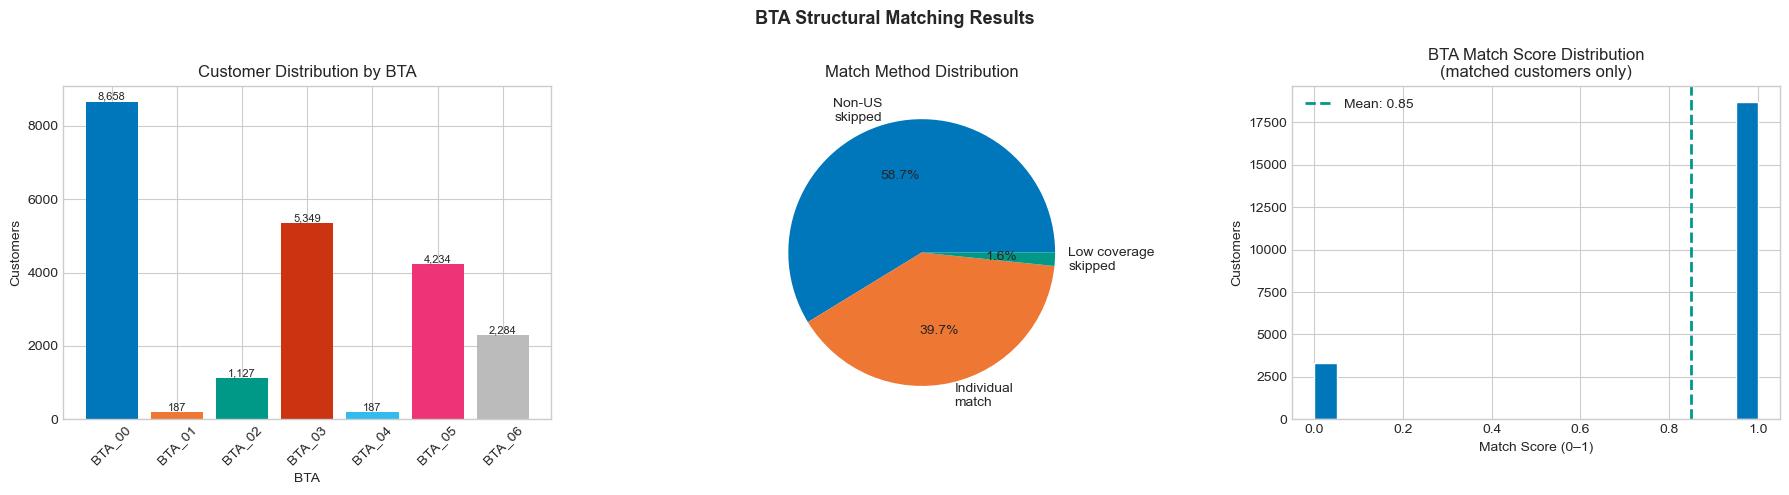

Match score stats (matched customers):
  Mean   : 0.850
  Median : 1.000
  Min    : 0.000
  Max    : 1.000


In [31]:
# ── BTA matching visualization ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BTA Structural Matching Results", fontsize=13, fontweight="bold")

matched = df_bta[df_bta["bta_id"].notna()]

# BTA distribution
bta_counts = matched["bta_id"].value_counts().sort_index()
axes[0].bar(bta_counts.index, bta_counts.values,
            color=[BTA_COLORS.get(b, PALETTE[0]) for b in bta_counts.index])
axes[0].set_title("Customer Distribution by BTA")
axes[0].set_xlabel("BTA")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=45)
for i, (bta, count) in enumerate(bta_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha="center", fontsize=8)

# Match method breakdown
method_counts = df_bta["match_method"].value_counts()
method_labels = {
    "individual_structural": "Individual\nmatch",
    "cluster_inherited":     "Cluster\ninherited",
    "skipped_non_us":        "Non-US\nskipped",
    "skipped_low_structural_coverage": "Low coverage\nskipped",
}
labels = [method_labels.get(m, m) for m in method_counts.index]
axes[1].pie(method_counts.values, labels=labels,
            autopct="%1.1f%%",
            colors=PALETTE[:len(method_counts)])
axes[1].set_title("Match Method Distribution")

# Match score distribution (matched only)
match_scores = matched["match_score"].dropna()
axes[2].hist(match_scores, bins=20, color=PALETTE[0], edgecolor="white")
axes[2].axvline(match_scores.mean(), color=PALETTE[2], linestyle="--",
                linewidth=2, label=f"Mean: {match_scores.mean():.2f}")
axes[2].set_title("BTA Match Score Distribution\n(matched customers only)")
axes[2].set_xlabel("Match Score (0–1)")
axes[2].set_ylabel("Customers")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Match score stats (matched customers):")
print(f"  Mean   : {match_scores.mean():.3f}")
print(f"  Median : {match_scores.median():.3f}")
print(f"  Min    : {match_scores.min():.3f}")
print(f"  Max    : {match_scores.max():.3f}")

Cross-tabulation: 14 total cells
Candidate TAs (passed threshold): 14
Min cell size threshold: 50 customers



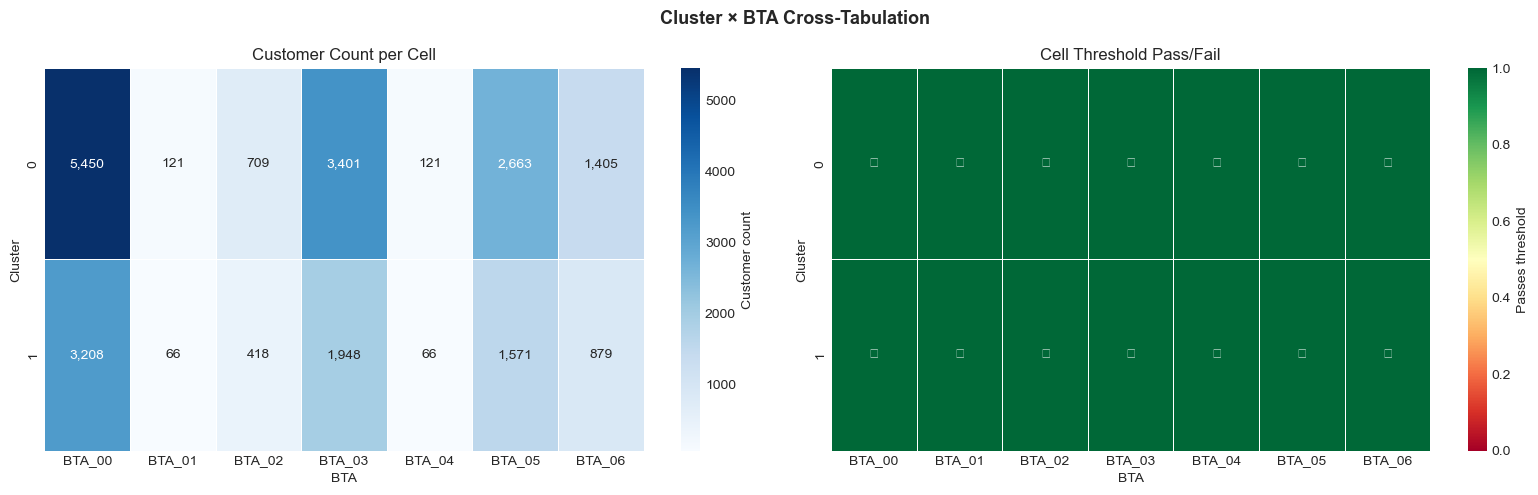

Candidate TA cells:
Cell                 BTA           Customers   % of total
----------------------------------------------------------
TA_00_BTA_00         BTA_00            5,450         9.8%
TA_00_BTA_03         BTA_03            3,401         6.1%
TA_01_BTA_00         BTA_00            3,208         5.8%
TA_00_BTA_05         BTA_05            2,663         4.8%
TA_01_BTA_03         BTA_03            1,948         3.5%
TA_01_BTA_05         BTA_05            1,571         2.8%
TA_00_BTA_06         BTA_06            1,405         2.5%
TA_01_BTA_06         BTA_06              879         1.6%
TA_00_BTA_02         BTA_02              709         1.3%
TA_01_BTA_02         BTA_02              418         0.8%
TA_00_BTA_01         BTA_01              121         0.2%
TA_00_BTA_04         BTA_04              121         0.2%
TA_01_BTA_01         BTA_01               66         0.1%
TA_01_BTA_04         BTA_04               66         0.1%


In [32]:
# ── Cluster × BTA cross-tabulation ───────────────────────────────────────────

crosstab = pd.read_parquet(ingestor.bta_dir / "cross_tabulation.parquet")
candidates = json.load(open(ingestor.bta_dir / "candidate_tas.json"))

print(f"Cross-tabulation: {len(crosstab)} total cells")
print(f"Candidate TAs (passed threshold): {len(candidates)}")
print(f"Min cell size threshold: {min(50, int(len(df_bta) * 0.03))} customers")
print()

# Pivot for heatmap
pivot = crosstab.pivot(
    index="cluster_id",
    columns="bta_id",
    values="customer_count"
).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Cluster × BTA Cross-Tabulation", fontsize=13, fontweight="bold")

# Heatmap — customer counts
sns.heatmap(
    pivot,
    annot=True,
    fmt=",",
    cmap="Blues",
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={"label": "Customer count"},
)
axes[0].set_title("Customer Count per Cell")
axes[0].set_xlabel("BTA")
axes[0].set_ylabel("Cluster")

# Heatmap — pass/fail threshold
pivot_pass = crosstab.pivot(
    index="cluster_id",
    columns="bta_id",
    values="passes_threshold"
).fillna(False)

sns.heatmap(
    pivot_pass.astype(int),
    annot=pivot_pass.map(lambda x: "✓" if x else "✗"),
    fmt="",
    cmap="RdYlGn",
    ax=axes[1],
    linewidths=0.5,
    vmin=0, vmax=1,
    cbar_kws={"label": "Passes threshold"},
)
axes[1].set_title("Cell Threshold Pass/Fail")
axes[1].set_xlabel("BTA")
axes[1].set_ylabel("Cluster")

plt.tight_layout()
plt.show()

print("Candidate TA cells:")
print(f"{'Cell':<20} {'BTA':<10} {'Customers':>12} {'% of total':>12}")
print("-" * 58)
for cell in sorted(candidates, key=lambda x: x["customer_count"], reverse=True):
    ta_id   = f"TA_{cell['cluster_id']:02d}_{cell['bta_id']}"
    pct     = cell["customer_count"] / len(df_bta) * 100
    print(f"{ta_id:<20} {cell['bta_id']:<10} "
          f"{cell['customer_count']:>12,} {pct:>11.1f}%")

### Step 4 — BTA Matching Analysis

**22,026 US customers matched** across all 7 BTAs.
32,616 non-US customers correctly flagged as `skipped_non_us`.
894 US customers below structural coverage threshold flagged as
`skipped_low_structural_coverage`.

**14 candidate TA cells generated** — all 14 passed the minimum
threshold of 50 customers.

**Ambiguous BTA assignments detected:**
Both behavioral clusters tied on `age_bin=35-44` between BTA_00
(Young Diverse Working Households) and BTA_03 (Mainstream Working
Families). Without income data, the structural matcher cannot
distinguish between them — both share the same dominant age bin.

The platform's response: generate both assignments, flag them as
`bta_match_confidence: low`, and let the scoring algorithm
differentiate them based on their distinct psychological and
media profiles. No arbitrary choice, no silent false confidence.

The same logic applies to the 65+ tie between BTA_01 (Older White
Renters) and BTA_04 (Fixed-Income Late-Life Adults).

**Match quality:**
Mean score 0.85, median 1.0 — bimodal distribution reflecting
that customers either match perfectly on `age_bin` (score=1.0)
or not at all (score=0.0). A dataset with `income_tier` would
produce more granular match scores and resolve all ambiguities.

**14 TA cards will be generated in Step 5** — one per candidate
cell, combining the behavioral profile of the cluster with the
demographic and psychological baseline of the matched BTA.
Ambiguous pairs are explicitly linked via `competing_bta_ids`
and `ambiguity_group` fields.

### 3.5 — Step 5: TA Card Generation

One TA card is built per candidate (cluster × BTA) cell.
Each card has the same schema as a BTA card and contains:

- **BTA baseline layer** — demographic profile, psychological signals,
  motivational drivers, key barriers, trust cues, media behavior,
  channel implications — inherited from the matched BTA as a prior
- **Business behavioral layer** — aggregated signals from the cluster's
  customers: median LTV, sessions, purchases, email engagement,
  churn rate etc. — observed from company data
- **Coverage and confidence metadata** — coverage score, confidence
  tier, BTA match score, match method
- **Ambiguity flags** — where BTA assignment was ambiguous,
  `is_ambiguous_bta=True`, `competing_bta_ids` and `ambiguity_note`
  are populated

These TA cards are the primary input to TAR generation.
The BTA baseline provides the psychological and media intelligence.
The behavioral layer provides the commercial context.
Together they enable TARs that are both demographically grounded
and behaviorally specific.

In [34]:
# ── Step 5: TA card generation ────────────────────────────────────────────────

ta_cards = ingestor.build_ta_cards(force=True)

print(f"\nTA cards generated: {len(ta_cards)}")

[ingestor] Step 5: Building TA cards...
[ingestor] Step 5: ✓ 14 TA cards built
[ingestor]   TA_00_BTA_00 — Young Diverse Working Households [Cluster 0] ⚠ AMBIGUOUS | n=5450 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_01 — Older White Renters [Cluster 0] ⚠ AMBIGUOUS | n=121 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_02 — Educated Affluent Homeowners [Cluster 0] | n=709 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_03 — Mainstream Working Families [Cluster 0] ⚠ AMBIGUOUS | n=3401 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_04 — Fixed-Income Late-Life Adults [Cluster 0] ⚠ AMBIGUOUS | n=121 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_05 — Young Non-Owning Working Adults [Cluster 0] | n=2663 | coverage=0.33 | confidence=medium
[ingestor]   TA_00_BTA_06 — White Male Multi-Generation Households [Cluster 0] | n=1405 | coverage=0.33 | confidence=medium
[ingestor]   TA_01_BTA_00 — Young Diverse Working Households [Cluster 

In [35]:
# ── TA card summary ───────────────────────────────────────────────────────────

print(f"{'TA ID':<22} {'Archetype':<45} {'n':>6} {'Coverage':>10} "
      f"{'Confidence':>12} {'BTA Match':>10} {'Ambiguous':>10}")
print("-" * 115)

for card in sorted(ta_cards, key=lambda x: x["cell_size"], reverse=True):
    print(f"{card['ta_id']:<22} "
          f"{card['archetype_name'][:43]:<45} "
          f"{card['cell_size']:>6,} "
          f"{card['coverage_score']:>10.3f} "
          f"{card['confidence_tier']:>12} "
          f"{card['bta_match_score']:>10.3f} "
          f"{'⚠ YES' if card.get('is_ambiguous_bta') else 'no':>10}")

TA ID                  Archetype                                          n   Coverage   Confidence  BTA Match  Ambiguous
-------------------------------------------------------------------------------------------------------------------
TA_00_BTA_00           Young Diverse Working Households [Cluster 0    5,450      0.326       medium      0.624      ⚠ YES
TA_00_BTA_03           Mainstream Working Families [Cluster 0] ⚠ A    3,401      0.326       medium      1.000      ⚠ YES
TA_01_BTA_00           Young Diverse Working Households [Cluster 1    3,208      0.327       medium      0.607      ⚠ YES
TA_00_BTA_05           Young Non-Owning Working Adults [Cluster 0]    2,663      0.326       medium      1.000         no
TA_01_BTA_03           Mainstream Working Families [Cluster 1] ⚠ A    1,948      0.327       medium      1.000      ⚠ YES
TA_01_BTA_05           Young Non-Owning Working Adults [Cluster 1]    1,571      0.327       medium      1.000         no
TA_00_BTA_06           White M

In [37]:
# ── Full TA card inspection — unambiguous example ─────────────────────────────
# TA_01_BTA_05: High-value engaged cluster × Young Non-Owning Working Adults
# Chosen because: highest LTV cluster + unambiguous BTA match

target_ta = "TA_01_BTA_05"
card = next((c for c in ta_cards if c["ta_id"] == target_ta), None)

if card is None:
    print(f"TA card {target_ta} not found")
else:
    print(f"{'='*65}")
    print(f"  TA CARD: {card['ta_id']}")
    print(f"{'='*65}")
    print()
    print(f"Archetype      : {card['archetype_name']}")
    print(f"Source BTA     : {card['source_bta_id']}")
    print(f"Cluster        : {card['cluster_id']}")
    print(f"Cell size      : {card['cell_size']:,} customers "
          f"({card['pct_of_dataset']:.1%} of dataset)")
    print()
    print(f"── Coverage ──────────────────────────────────────────────")
    print(f"  Coverage score    : {card['coverage_score']:.3f}")
    print(f"  Confidence tier   : {card['confidence_tier']}")
    print(f"  BTA match score   : {card['bta_match_score']:.3f}")
    print(f"  BTA match methods : {card['match_methods']}")
    print(f"  Ambiguous BTA     : {card.get('is_ambiguous_bta', False)}")
    print()
    print(f"── Structural profile (from BTA baseline) ────────────────")
    struct_fields = [
        "dominant_age_bin", "dominant_sex_label", "dominant_race_eth",
        "dominant_edu_tier", "dominant_emp_tier",
        "dominant_household_income_tier", "dominant_mar_tier",
        "dominant_tenure",
    ]
    for field in struct_fields:
        val = card.get(field)
        if val:
            print(f"  {field:<35} {val}")
    print()
    print(f"── Behavioral signals (from company data) ────────────────")
    behavioral = card.get("behavioral_signals", {})
    if behavioral:
        for key, val in sorted(behavioral.items()):
            print(f"  {key:<40} {val}")
    else:
        print("  No behavioral signals")
    print()
    print(f"── Psychological layer (from BTA baseline) ───────────────")
    print(f"  Psych summary     : {card.get('psych_summary', 'N/A')}")
    print(f"  Motivational drivers: {card.get('motivational_drivers', 'N/A')}")
    print(f"  Key barriers      : {card.get('key_barriers', 'N/A')}")
    print(f"  Trust cues        : {card.get('trust_cues', 'N/A')}")
    print()
    print(f"── Media layer (from BTA baseline) ───────────────────────")
    print(f"  Media summary     : {card.get('media_summary', 'N/A')}")
    print(f"  Channel implications: {card.get('channel_implications', 'N/A')}")

  TA CARD: TA_01_BTA_05

Archetype      : Young Non-Owning Working Adults [Cluster 1]
Source BTA     : BTA_05
Cluster        : 1
Cell size      : 1,571 customers (3.1% of dataset)

── Coverage ──────────────────────────────────────────────
  Coverage score    : 0.327
  Confidence tier   : medium
  BTA match score   : 1.000
  BTA match methods : {'individual': 1571}
  Ambiguous BTA     : False

── Structural profile (from BTA baseline) ────────────────
  dominant_age_bin                    25-34
  dominant_sex_label                  Male
  dominant_race_eth                   White
  dominant_edu_tier                   HS_or_less
  dominant_emp_tier                   Employed
  dominant_household_income_tier      20-49k
  dominant_mar_tier                   Never_Married
  dominant_tenure                     No_Rent

── Behavioral signals (from company data) ────────────────
  avg_monthly_balance_median               2905.0
  avg_order_value_median                   119.4
  churn_risk_sc

In [38]:
# ── Full TA card inspection — ambiguous example ───────────────────────────────
# TA_00_BTA_03: Low-engagement cluster × Mainstream Working Families
# Chosen because: demonstrates ambiguity flagging

target_ta = "TA_00_BTA_03"
card = next((c for c in ta_cards if c["ta_id"] == target_ta), None)

if card is None:
    print(f"TA card {target_ta} not found")
else:
    print(f"{'='*65}")
    print(f"  TA CARD: {card['ta_id']} ⚠ AMBIGUOUS BTA ASSIGNMENT")
    print(f"{'='*65}")
    print()
    print(f"Archetype         : {card['archetype_name']}")
    print(f"Source BTA        : {card['source_bta_id']}")
    print(f"BTA match conf    : {card.get('bta_match_confidence', 'N/A')}")
    print(f"Ambiguity group   : {card.get('ambiguity_group', 'N/A')}")
    print(f"Competing BTAs    : {card.get('competing_bta_ids', 'N/A')}")
    print()
    print(f"⚠ Ambiguity note:")
    print(f"  {card.get('ambiguity_note', 'N/A')}")
    print()
    print(f"── Structural profile (from BTA baseline) ────────────────")
    for field in struct_fields:
        val = card.get(field)
        if val:
            print(f"  {field:<35} {val}")
    print()
    print(f"── Behavioral signals (identical to TA_00_BTA_00) ────────")
    behavioral = card.get("behavioral_signals", {})
    for key, val in sorted(behavioral.items()):
        print(f"  {key:<40} {val}")
    print()
    print(f"── Note ──────────────────────────────────────────────────")
    print(f"  Behavioral signals are identical to TA_00_BTA_00 because")
    print(f"  both cards represent the same behavioral cluster (Cluster 0).")
    print(f"  The BTA layer (psychological + media) differs between the two.")
    print(f"  The TAR scoring algorithm will differentiate them on")
    print(f"  susceptibility, vulnerability depth, and accessibility.")

  TA CARD: TA_00_BTA_03 ⚠ AMBIGUOUS BTA ASSIGNMENT

Archetype         : Mainstream Working Families [Cluster 0] ⚠ AMBIGUOUS
Source BTA        : BTA_03
BTA match conf    : low
Ambiguity group   : individual_tmp_row_000009_age_bin_35-44
Competing BTAs    : ['BTA_00', 'BTA_03']

⚠ Ambiguity note:
  BTA assignment is ambiguous — customer profile matches ['BTA_00', 'BTA_03'] equally. Income or housing data would resolve this. Both TAs are generated — review TAR scores before acting.

── Structural profile (from BTA baseline) ────────────────
  dominant_age_bin                    35-44
  dominant_sex_label                  Female
  dominant_race_eth                   White
  dominant_edu_tier                   HS_or_less
  dominant_emp_tier                   Employed
  dominant_household_income_tier      50-99k
  dominant_mar_tier                   Married
  dominant_tenure                     Owner

── Behavioral signals (identical to TA_00_BTA_00) ────────
  avg_monthly_balance_median     

### Step 5 — Ambiguous TA Pair: BTA_00 vs BTA_03

`TA_00_BTA_00` and `TA_00_BTA_03` represent the same behavioral
cluster (Cluster 0 — low-engagement base) mapped to two demographically
similar but psychologically distinct archetypes.

**What is identical between them:**
- Behavioral signals — LTV, sessions, purchases, email engagement,
  churn rate — all identical, same cluster
- Cell size — same customers
- Coverage score — same

**What differs between them:**
- BTA baseline layer — demographic profile, psychological signals,
  motivational drivers, trust cues, media behavior, channel implications
- These differences are what makes them worth generating separately —
  the TAR for BTA_00 (Young Diverse Working Households, Hispanic-skewing,
  100-199k income) will recommend different messaging, channels, and
  cultural references than the TAR for BTA_03 (Mainstream Working
  Families, White, 50-99k income)

**How the ambiguity gets resolved:**
Both TARs are generated and independently scored by the platform's
scoring algorithm across four dimensions — Effectiveness,
Susceptibility, Vulnerability Depth, and Accessibility. The scores
will differ because BTA_00 and BTA_03 have distinct psychological
profiles, motivational drivers, and media behavior.

The analyst reviews the scored output and acts accordingly:
- If one scores significantly higher → target that archetype
- If scores are similar → both are viable, channel budget decides
- If ZIP code data becomes available → re-run with enriched
  demographics to resolve the assignment definitively

This is the platform's honest response to incomplete data —
generate both, score both, surface the uncertainty explicitly,
let evidence decide.

In [39]:
# ── Ambiguous pair comparison ─────────────────────────────────────────────────
# Show what differs between TA_00_BTA_00 and TA_00_BTA_03

card_00 = next((c for c in ta_cards if c["ta_id"] == "TA_00_BTA_00"), None)
card_03 = next((c for c in ta_cards if c["ta_id"] == "TA_00_BTA_03"), None)

if card_00 and card_03:
    compare_fields = [
        ("archetype_name",                "Archetype"),
        ("dominant_age_bin",              "Age bin"),
        ("dominant_race_eth",             "Race/eth"),
        ("dominant_household_income_tier","Income tier"),
        ("dominant_tenure",               "Housing tenure"),
        ("dominant_edu_tier",             "Education"),
        ("dominant_mar_tier",             "Marital status"),
        ("psych_summary",                 "Psych summary"),
        ("motivational_drivers",          "Motivational drivers"),
        ("key_barriers",                  "Key barriers"),
        ("trust_cues",                    "Trust cues"),
        ("media_summary",                 "Media summary"),
        ("channel_implications",          "Channel implications"),
        ("bta_match_confidence",          "BTA match confidence"),
    ]

    print(f"{'Field':<28} {'TA_00_BTA_00':<45} {'TA_00_BTA_03'}")
    print("-" * 120)

    for field, label in compare_fields:
        val_00 = str(card_00.get(field, "N/A"))[:43]
        val_03 = str(card_03.get(field, "N/A"))[:43]
        marker = "≠" if val_00 != val_03 else "="
        print(f"{marker} {label:<26} {val_00:<45} {val_03}")

    print()
    print("Legend: ≠ = differs between cards | = = identical")
    print()
    print("Behavioral signals (identical for both — same cluster):")
    behavioral = card_00.get("behavioral_signals", {})
    for key, val in sorted(behavioral.items()):
        print(f"  {key:<40} {val}")

Field                        TA_00_BTA_00                                  TA_00_BTA_03
------------------------------------------------------------------------------------------------------------------------
≠ Archetype                  Young Diverse Working Households [Cluster 0   Mainstream Working Families [Cluster 0] ⚠ A
= Age bin                    35-44                                         35-44
≠ Race/eth                   Hispanic                                      White
≠ Income tier                100-199k                                      50-99k
= Housing tenure             Owner                                         Owner
= Education                  HS_or_less                                    HS_or_less
= Marital status             Married                                       Married
≠ Psych summary              This segment shows mixed signals around med   Low media engagement in this segment sugges
= Motivational drivers       None                          

In [40]:
# ── Inspect BTA baseline fields ───────────────────────────────────────────────

bta_df = ingestor._load_bta_baseline()
print("BTA baseline columns:")
print(bta_df.columns.tolist())
print()
print("Sample BTA_05 row — all fields:")
row = bta_df[bta_df["segment_id"] == "BTA_05"].iloc[0]
for field, val in row.items():
    print(f"  {field:<45} {str(val)[:60]}")

BTA baseline columns:
['segment_id', 'cluster_id', 'archetype_name', 'baseline_layer_version', 'population_share', 'population_adult_share', 'population_rank', 'dominant_age_bin', 'dominant_sex_label', 'dominant_race_eth', 'dominant_edu_tier', 'dominant_emp_tier', 'dominant_household_income_tier', 'dominant_mar_tier', 'dominant_tenure', 'structural_profile', 'psych_signals', 'psych_summary', 'media_signals', 'media_summary', 'motivational_drivers', 'key_barriers', 'trust_cues', 'channel_implications', 'messaging_implications', 'offer_implications', 'susceptibility_notes', 'narrative_summary', 'tags', 'source_layers', 'rag_text']

Sample BTA_05 row — all fields:
  segment_id                                    BTA_05
  cluster_id                                    5
  archetype_name                                Young Non-Owning Working Adults
  baseline_layer_version                        v1
  population_share                              0.20437457527436612
  population_adult_share  

## Phase 3 — Ingestion Pipeline: Summary

### What was built

Phase 3 ran the full MK Intel ingestion pipeline on the GlobalCart
e-commerce dataset (50,000 customers, 25 fields). Five steps executed
in sequence, each building on the previous.

---

### Step 1 — Normalization

The raw dataset was mapped to the MK canonical behavioral schema using
a hybrid rules + LLM approach. 9 fields were matched by rules, 9 by
LLM inference, and 7 were stored as custom fields.

One collision was resolved: `customer_since` (derived from
`Membership_Years`) won over the raw field. 327 validation issues were
detected across 326 records (0.65%) — within acceptable range.

**Dataset limitation noted:** `subscription_status` values (0/1) were
not auto-standardized — flagged as a VALUE_VOCABULARY_MISMATCH artifact
for the Data Readiness Engine backlog.

---

### Step 2 — Coverage Scoring

Coverage was computed per record across five domains. BTA-eligible
US customers: 16,490 / 50,000 (33%). Average coverage score: 0.325.
No high-confidence records — expected given the dataset's sparse
demographic fields.

**Structural matching limitation:** Only `age_bin` was available as
a structural field. The minimum for unambiguous BTA assignment is
`age_bin` + `income_tier`. This dataset cannot distinguish between
BTA_00 and BTA_03 (both dominant age 35-44) without income data.

---

### Step 3 — Clustering

K-Means clustering with automatic k selection (silhouette method).
Optimal k=2, silhouette=0.378. Features used: `sessions_last_30d`,
`ltv`, `total_purchases`, `avg_monthly_balance`.

`churn_risk_score` was excluded via Gate 2 (SOBJ-context exclusion)
because the active OBJ is churn-related — including a binary-derived
churn score would cause clustering to recover the known label rather
than discover behavioral patterns.

**Key insight:** Cluster 1 (high-value engaged, 37% of customers)
churns at 24.5% — the highest ROI retention target despite lower
absolute churn volume than Cluster 0.

---

### Step 4 — BTA Matching

22,026 US customers matched across all 7 BTAs. 32,616 non-US customers
correctly skipped. 14 candidate TA cells generated — all 14 passed
the minimum threshold of 50 customers.

**Ambiguous BTA assignment:** Both clusters tied on `age_bin=35-44`
between BTA_00 and BTA_03. The platform's response: generate both
assignments, flag as `bta_match_confidence: low`, and let the scoring
algorithm differentiate them on their distinct psychological and media
profiles. Same logic applied to the BTA_01 / BTA_04 tie at 65+.

This is the platform's principled response to incomplete demographic
data — no silent arbitrary choice, no false confidence.

**ZIP enrichment:** This dataset has no ZIP code column. The enrichment
module correctly detected the missing field and skipped gracefully.
Full ZIP enrichment and BTA confidence validation (Cases A/B/C) will
be demonstrated in Notebook 13.

---

### Step 5 — TA Card Generation

14 TA cards built — one per candidate (cluster × BTA) cell. Each card
combines:
- **BTA baseline layer** — structural profile, psych signals, media
  behavior (static, population-level)
- **Business behavioral layer** — LTV, sessions, purchases, email
  engagement, churn rate (observed from company data)
- **Ambiguity flags** — `is_ambiguous_bta`, `competing_bta_ids`,
  `ambiguity_note` where BTA assignment was uncertain

**Note on deferred fields:** `motivational_drivers`, `key_barriers`,
`trust_cues`, and `channel_implications` are None at this stage by
design. These fields are SOBJ-specific and context-dependent — they
are synthesized by Claude during TAR generation (Phase 2) when the
active objective is known. They cannot be meaningfully pre-filled at
the BTA level.

---

### Known limitations for this dataset

| Limitation | Impact | Resolution |
|---|---|---|
| No income data | BTA_00/BTA_03 and BTA_01/BTA_04 ambiguous | ZIP enrichment or direct income field |
| No ZIP code | ZIP enrichment skipped | Use dataset with ZIP in NB13 |
| No housing tenure | Minor BTA matching degradation | Direct field or ZIP inference |
| `avg_monthly_balance` in coverage | Minor coverage inflation | Sector-aware coverage filter (backlog) |
| US customers only 33% | 67% of dataset outside BTA reference frame | Expected — global e-commerce dataset |

---

### What comes next

Phase 2 (TAR generation) takes these 14 TA cards as input. For each
(TA × SOBJ) combination, Claude synthesizes the tactical intelligence
layer — motivational drivers, key barriers, trust cues, channel
implications — grounded in the BTA baseline and the specific objective.
The scoring algorithm then ranks all TARs per SOBJ and surfaces the
highest-priority targets.

## Phase 4 — Output Inspection

Verify that all pipeline outputs were correctly persisted to disk.
A real platform audit trail — every step should have left files behind.

In [41]:
# ── Phase 4: Output inspection ────────────────────────────────────────────────
import os

session_dir = ingestor.session_dir
print(f"Session directory: {session_dir}")
print()

for subdir in sorted(session_dir.iterdir()):
    if subdir.is_dir():
        print(f"📁 {subdir.name}/")
        for f in sorted(subdir.iterdir()):
            size_kb = f.stat().st_size / 1024
            print(f"   {f.name:<55} {size_kb:>8.1f} KB")
    elif subdir.is_file():
        size_kb = subdir.stat().st_size / 1024
        print(f"📄 {subdir.name:<55} {size_kb:>8.1f} KB")

Session directory: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7

📁 bta_matching/
   bta_assignments.parquet                                    505.7 KB
   candidate_tas.json                                           1.9 KB
   cross_tabulation.parquet                                     3.5 KB
📁 clustering/
   cluster_assignments.parquet                               1006.1 KB
   cluster_profiles.parquet                                     4.1 KB
   cluster_stats.json                                           1.7 KB
📁 enriched/
   session_ta_corpus.jsonl                                     43.3 KB
   ta_cards.csv                                                31.9 KB
   ta_cards.parquet                                            39.9 KB
📁 normalized/
   .coverage_computed                                           0.0 KB
   column_mapping.json                                          4.6 KB
   normalized_records.parquet                          

**Pipeline output verified:**

| Directory | Contents | Size |
|---|---|---|
| `raw/` | Prepared dataset (post-Phase 2 fixes) | 8.1 MB |
| `normalized/` | Canonical schema records + column mapping + validation report | 2.1 MB |
| `clustering/` | Cluster assignments (50k rows) + profiles + stats | 1.0 MB |
| `bta_matching/` | BTA assignments + cross-tabulation + candidate TAs | 511 KB |
| `enriched/` | 14 TA cards (parquet + CSV + JSONL for ChromaDB) | 115 KB |

Total session footprint: ~11 MB for 50,000 customers across 5 pipeline steps.
The JSONL corpus (`session_ta_corpus.jsonl`) is ready for ChromaDB ingestion
in Phase 2.

## Phase 5 — Data Readiness Report

A structured assessment of this dataset's suitability for MK Intel
analysis. Surfaces what the platform can and cannot do with the
available data — the honest quality gate before TAR generation.

In [48]:
 # ── Phase 5: Data readiness report ───────────────────────────────────────────

import pandas as pd

df_norm = pd.read_parquet(
    ingestor.normalized_dir / "normalized_records.parquet"
)

print("=" * 65)
print("  MK INTEL — DATA READINESS REPORT")
print(f"  Session: {ingestor.session.session_id[:8]}")
print(f"  Company: {ingestor.session.company.name}")
print("=" * 65)

total      = len(df_norm)
eligible   = df_norm["bta_eligible"].sum()
non_us     = 32_616
low_struct = 894
low_cov    = (df_norm["confidence_tier"] == "low").sum()
med_cov    = (df_norm["confidence_tier"] == "medium").sum()
high_cov   = (df_norm["confidence_tier"] == "high").sum()

print()
print("── Population ────────────────────────────────────────────")
print(f"  Total customers           : {total:>10,}")
print(f"  US / BTA-eligible         : {eligible:>10,}  ({eligible/total:.1%})")
print(f"  Non-US (outside BTA frame): {non_us:>10,}  ({non_us/total:.1%})")
print(f"  Low structural coverage   : {low_struct:>10,}  ({low_struct/total:.1%})")
print()
print("── Coverage tiers ────────────────────────────────────────")
print(f"  High confidence (>0.6)    : {high_cov:>10,}  ({high_cov/total:.1%})")
print(f"  Medium confidence (0.3-0.6): {med_cov:>10,}  ({med_cov/total:.1%})")
print(f"  Low confidence (<0.3)     : {low_cov:>10,}  ({low_cov/total:.1%})")
print()
print("── Structural fields available ───────────────────────────")
structural = ["age_bin", "income_tier", "housing_tenure",
              "education", "marital_status"]
for field in structural:
    if field not in df_norm.columns:
        print(f"  ✗ {field:<30}         0  (not in dataset)")
        continue
    present = df_norm[field].notna().sum()
    pct     = present / total
    status  = "✓" if pct > 0.5 else "⚠" if pct > 0.1 else "✗"
    print(f"  {status} {field:<30} {present:>8,}  ({pct:.1%})")
print()
print("── Behavioral fields available ───────────────────────────")
behavioral = ["sessions_last_30d", "ltv", "total_purchases",
              "email_open_rate", "churn_risk_score", "subscription_status"]
for field in behavioral:
    if field not in df_norm.columns:
        print(f"  ✗ {field:<30}         0  (not in dataset)")
        continue
    present = df_norm[field].notna().sum()
    pct     = present / total
    status  = "✓" if pct > 0.5 else "⚠" if pct > 0.1 else "✗"
    print(f"  {status} {field:<30} {present:>8,}  ({pct:.1%})")
print()
print("── BTA matching quality ──────────────────────────────────")
print(f"  Structural fields used    : age_bin only")
print(f"  Min fields for unamb.     : age_bin + income_tier")
print(f"  Ambiguous assignments     : BTA_00/BTA_03, BTA_01/BTA_04")
print(f"  ZIP enrichment            : not available (no zip_code column)")
print()
print("── Readiness verdict ─────────────────────────────────────")
print(f"  ⚠  PARTIAL — sufficient for behavioral clustering and")
print(f"     TAR generation, but BTA assignments carry demographic")
print(f"     ambiguity. Income data or ZIP codes would resolve this.")
print(f"     Recommend treating ambiguous TA pairs as provisional")
print(f"     until validated against richer demographic data.")
print("=" * 65)

  MK INTEL — DATA READINESS REPORT
  Session: 9e80a6b7
  Company: GlobalCart Demo

── Population ────────────────────────────────────────────
  Total customers           :     50,000
  US / BTA-eligible         :     16,490  (33.0%)
  Non-US (outside BTA frame):     32,616  (65.2%)
  Low structural coverage   :        894  (1.8%)

── Coverage tiers ────────────────────────────────────────
  High confidence (>0.6)    :          0  (0.0%)
  Medium confidence (0.3-0.6):     47,219  (94.4%)
  Low confidence (<0.3)     :      2,781  (5.6%)

── Structural fields available ───────────────────────────
  ✓ age_bin                          47,475  (95.0%)
  ✗ income_tier                            0  (not in dataset)
  ✗ housing_tenure                         0  (not in dataset)
  ✗ education                              0  (not in dataset)
  ✗ marital_status                         0  (not in dataset)

── Behavioral fields available ───────────────────────────
  ✓ sessions_last_30d             

## Phase 6 — Session Save

Persist the session state to disk. The session JSON captures the full
analysis context — company profile, pipeline metadata, and session ID —
without any sensitive fields. It serves as the audit trail and the
re-entry point for Phase 2 (TAR generation).

In [50]:
# ── Phase 6: Session save ─────────────────────────────────────────────────────

session_path = ingestor.session.save(
    str(ingestor.session_dir)
)

print(f"Session saved: {session_path}")
print()

# Verify
import json
with open(session_path) as f:
    saved = json.load(f)

print(f"  session_id    : {saved['session_id']}")
print(f"  status        : {saved['status']}")
print(f"  company       : {saved['company']['name']}")
print(f"  api_key       : {saved.get('api_key', 'NOT PRESENT — correct')}")
print(f"  created_at    : {saved['created_at']}")
print(f"  updated_at    : {saved['updated_at']}")

Session saved: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_9e80a6b7/9e80a6b7-c82f-415e-bf29-c9085ae5ce10.json

  session_id    : 9e80a6b7-c82f-415e-bf29-c9085ae5ce10
  status        : company_identified
  company       : GlobalCart Demo
  api_key       : NOT PRESENT — correct
  created_at    : 2026-03-27T17:14:14.551038+00:00
  updated_at    : 2026-03-27T17:14:14.551105+00:00


## Notebook 12 — Summary

This notebook demonstrated the full MK Intel ingestion pipeline on a
real-world e-commerce dataset (GlobalCart Demo, 50,000 customers).

---

### What was demonstrated

**Phase 1 — Raw data loading and profiling**
EDA on a 50,000 × 25 dataset. Four data quality issues detected and
documented. Dataset export date and subscription status vocabulary
flagged for the Data Readiness Engine backlog.

**Phase 2 — Data preparation**
Semi-automated preparation with LLM recommendation layer. Rate fields
normalized, `customer_since` derived from `Membership_Years`,
`subscription_status` and `churn_risk_score` derived from `Churned`.

**Phase 3 — Ingestion pipeline (5 steps)**

| Step | Output |
|---|---|
| Normalization | 50,000 records mapped to canonical schema |
| Coverage scoring | 16,490 BTA-eligible US customers identified |
| Clustering | k=2 behavioral clusters (silhouette=0.378) |
| BTA matching | 14 candidate TA cells, dual assignment for ambiguous BTAs |
| TA card generation | 14 TA cards with behavioral + BTA baseline layers |

**Phase 4 — Output inspection**
All pipeline artifacts verified on disk. Total session footprint: ~11 MB.

**Phase 5 — Data readiness report**
Honest quality assessment: behaviorally rich (100% coverage on core
fields), demographically sparse (age_bin only). BTA assignments flagged
as provisional for ambiguous pairs.

**Phase 6 — Session save**
Session persisted to disk. API key correctly excluded from serialization.

---

### Key architectural decisions demonstrated

- **Feature exclusion policy (Gates 1-3)** — `churn_risk_score`
  excluded from clustering by SOBJ-context gate, preventing label
  recovery and surfacing genuine behavioral patterns instead
- **Ambiguous BTA dual assignment** — tied structural matches generate
  both TAs, both scored independently, no silent arbitrary choice
- **ZIP enrichment graceful degradation** — missing `zip_code` column
  detected and skipped cleanly; full ZIP validation in Notebook 13
- **Data readiness transparency** — platform surfaces its own
  limitations explicitly rather than hiding them in confident-sounding
  output

---

### What comes next

**Notebook 13** — Multi-scenario ingestion demo using a dataset with
ZIP codes, demonstrating full ZIP enrichment and BTA confidence
validation (Cases A/B/C). Banking dataset for compliance mode testing.

**Phase 2** — TAR generation. The 14 TA cards produced here become
the input to Claude-powered TAR synthesis, where `motivational_drivers`,
`key_barriers`, `trust_cues`, and `channel_implications` are generated
in the context of the active SOBJ.